# Prediction of Solar Energy Potential Based on Weather and Location Data

## Project Descrption

- The anticipated surge in electricity demand, projected to increase by approximately 30% by 2035 according to the US Department of Energy, necessitates substantial investments in sustainable renewable energy resources to meet this growth.

- Addressing this challenge could be facilitated through the adoption of solar energy, as suggested by the same report. It indicates the potential for solar energy to contribute up to 40% of the country's electricity supply by 2035, a significant increase from its current contribution of 3%.

- In order to enhance the solar energy infrastructure, identifying new locations with the utmost potential for consistent solar electricity generation becomes crucial. Utilizing predictive modeling, based on diverse features, can aid in pinpointing such sites.

## Goal

Analyzing the potential solar energy power (Watts) that can be generated based on the weather and location characteristics at a specific time.

## Reference and Source

- Paper Reference Source :

    Pasion C, Wagner T, Koschnick C, Schuldt S, Williams J, Hallinan K. Machine Learning Modeling of Horizontal Photovoltaics Using Weather and Location Data. Energies. 2020; 13(10):2570. https://doi.org/10.3390/en13102570

- Dataset Source :

    https://www.kaggle.com/datasets/saurabhshahane/northern-hemisphere-horizontal-photovoltaic

### Import Libraries and Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', None)
# pd.set_option('display.float_format', '{:.15f}'.format)
pd.reset_option('display.float_format')

# Requirements
print('numpy version : ',np.__version__)
print('pandas version : ',pd.__version__)
print('seaborn version : ',sns.__version__)

numpy version :  1.26.4
pandas version :  2.2.1
seaborn version :  0.13.2


#### Load Dataset (Jupyter Notebook)

In [2]:
df = pd.read_csv('Pasion et al dataset.csv')

#### Load Dataset (Google Colab)

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# df = pd.read_csv('/content/drive/MyDrive/Personal Projects/Prediction of Solar Energy Potential Based on Weather and Location Data/Pasion et al dataset.csv')

# Initial Data Understanding and Pre-Processing

In [5]:
# Checking basic data information
def check_data_information(df, cols):
    """
    This function provides detailed information about each column in a dataframe, including:
    - Data type of the column
    - Number of missing (null) values
    - Percentage of missing values
    - Total number of duplicated rows in the dataframe (not column-specific)
    - Number of unique values in the column
    - A sample of up to 5 unique values from the column

    Parameters:
    df (pd.DataFrame): The dataframe you want to check.
    cols (list): List of column names to check the information from.

    Returns:
    pd.DataFrame: A dataframe with detailed information for each column.
    """
    list_item = []
    for col in cols:
        list_item.append([col,                             # The column name
                          df[col].dtype,                   # The data type of the column
                          df[col].isna().sum(),            # The count of null values in the column
                          round(100 * df[col].isna().sum() / len(df[col]), 2),  # The percentage of null values
                          df.duplicated().sum(),           # The count of duplicated rows in the entire dataframe
                          df[col].nunique(),               # The count of unique values in the column
                          df[col].unique()[:5]])           # A sample of the first 5 unique values in the column

    desc_df = pd.DataFrame(data=list_item, columns='Feature, Data Type, Null Values, Null Percentage, Duplicated Values, Unique Values, Unique Sample'.split(","))
    return desc_df

columns_to_check = df.columns
check_data_information(df, columns_to_check)

,Feature,Data Type,Null Values,Null Percentage,Duplicated Values,Unique Values,Unique Sample
0,Location,object,0,0.0,0,12,"[Camp Murray, Grissom, Hill Weber, JDMT, Kahului]"
1,Date,int64,0,0.0,0,500,"[20171203, 20171204, 20171205, 20171206, 20171207]"
2,Time,int64,0,0.0,0,24,"[1145, 1315, 1330, 1230, 1415]"
3,Latitude,float64,0,0.0,0,12,"[47.11, 40.67, 41.15, 26.98, 20.89]"
4,Longitude,float64,0,0.0,0,12,"[-122.57, -86.15, -111.99, -80.11, -156.44]"
5,Altitude,int64,0,0.0,0,11,"[84, 239, 1370, 2, 1043]"
6,YRMODAHRMI,float64,0,0.0,0,18,"[201712000000.0, 201801000000.0, 201802000000.0, 201803000000.0, 201804000000.0]"
7,Month,int64,0,0.0,0,12,"[12, 1, 2, 3, 4]"
8,Hour,int64,0,0.0,0,6,"[11, 13, 12, 14, 15]"
9,Season,object,0,0.0,0,4,"[Winter, Spring, Summer, Fall]"


There are no missing or duplicated values in this dataset

## Feature Description (From Paper)

- **`Cloud Ceiling`:**
  - Definition: The presence of clouds above a panel scatters solar irradiance, decreasing the amount of irradiation received.
  - Measurement: Cloud ceiling is measured at the altitude where at least 5/8ths of the sky above the weather station is covered by clouds [17–25].

- **`Latitude`:**
  - Definition: Latitude of each location dictates the sun deflection angle, impacting the amount of sunlight received by the panel.
  - References: [12, 21–23, 25, 26].

- **`Month`:**
  - Definition: The time of year at a location determines the sun's rise, set, and its height in the sky.
  - References: [13, 21].

- **`Hour`:**
  - Definition: The time of day determines the sun's position, influencing the amount of sunlight received.
  - References: [21].

- **`Humidity`:**
  - Definition: Water affects incoming sunlight through refraction, diffraction, and reflection. Humidity indirectly affects dust build-up on panels.
  - Additional Info: Dew formation on the panel surface may enhance performance under humid conditions.
  - References: [27, 28].

- **`Temperature`:**
  - Definition: Solar panel efficiency generally decreases with increasing panel temperature.
  - Additional Info: Temperature as an explanatory variable enhances power output predictability.
  - References: [29, 30, 12, 13, 31–33].

- **`Wind Speed`:**
  - Definition: Wind speed may affect panel temperature and clean dust off the panel surface or stir up dust, influencing irradiance reaching the panel.
  - References: [34, 35, 36].

- **`Visibility`:**
  - Definition: Measurement of the distance at which light can be seen and identified.
  - Impact: Affects irradiation reaching the panel; low visibility during daylight hours may negatively impact power output.
  - References: [37].

- **`Pressure`:**
  - Definition: Pressure may indicate weather occurrences, such as storms, potentially affecting power output predictability.
  - Note: This variable has not been extensively explored in solar panel power output literature.
  - References: [38].

- **`Altitude`:**
  - Definition: Locations at higher altitudes have less atmosphere for the sun to travel through, resulting in higher irradiation.
  - Impact: Higher altitudes above sea level receive higher levels of irradiation.


## Target Description (From Paper)

**`PolyPwr`** means the amount of power output (Watts) recorded from Raspberry Pi computer system in polycrystalline PV panels at 15-min time intervals

In [6]:
# Checking the data samples
df.sample(20)

,Location,Date,Time,Latitude,Longitude,Altitude,YRMODAHRMI,Month,Hour,Season,Humidity,AmbientTemp,PolyPwr,Wind.Speed,Visibility,Pressure,Cloud.Ceiling
4550,Hill Weber,20180708,1300,41.15,-111.99,1370,2.018070e+11,7,13,Summer,15.11841,42.60071,21.77022,5,10.0,856.0,722
7250,Kahului,20180322,1000,20.89,-156.44,2,2.018030e+11,3,10,Spring,60.01587,27.79160,10.17723,18,10.0,1015.5,722
17251,Travis,20180226,1100,38.16,-121.56,1,2.018020e+11,2,11,Winter,79.37012,11.69846,4.43393,14,10.0,1012.6,722
14247,Peterson,20180103,1300,38.82,-104.71,1879,2.018010e+11,1,13,Winter,0.90332,20.73448,2.74528,14,10.0,815.9,722
5823,JDMT,20171113,1300,26.98,-80.11,2,2.017110e+11,11,13,Fall,58.08716,32.24541,31.62777,13,10.0,1017.2,90
12654,Offutt,20180625,1100,41.13,-95.75,380,2.018060e+11,6,11,Summer,99.98779,22.53967,0.66709,13,10.0,973.1,60
19650,USAFA,20180213,1215,38.95,-104.83,1947,2.018020e+11,2,12,Winter,46.54541,14.83551,13.80962,13,10.0,799.5,722
15695,Peterson,20180922,1000,38.82,-104.71,1879,2.018090e+11,9,10,Fall,11.18774,45.79063,9.98209,0,10.0,817.3,722
11858,MNANG,20180727,1300,44.89,-93.20,246,2.018070e+11,7,13,Summer,36.28540,30.93117,7.52641,13,10.0,988.5,722
3959,Hill Weber,20180306,1000,41.15,-111.99,1370,2.018030e+11,3,10,Spring,60.98022,0.05661,9.32480,15,10.0,863.1,722


Just from these information, there are some useful insight to this data that understanding it could make it easier for further analysis and feature transformation, they are :

- Date feature have the wrong format should be in datetime instead of integer.

- Time feature values are wrong because it's written in the format of hour:minute but because of it's data time is integer, it became hourminute (ex : 10:00 -> 1000).

- The hour feature only have 6 distinct values because the data is recorded during the peak hour only (11, 13, 12, 14, 15).

- Latitude and Longitude are useful if we want to make it into geographical plot in Tableau or similar tools, but in here it's already represented by Location, though i read that we could also do geospatial analysis and mapping in python using libraries like Arcpy, Geopandas, Geoplot, etc combined with specific tools/software but i haven't learn details of it right now probably later in the future.

- YRMODAHRMI (year, month, day, hour, minute) is actually similar to Date, but it has more detailed date information, probably will check what the values are like since it has so many digits.

- There are also separate feature for Month and Hour, we could use this and even though we could extract similar information in YRMODAHRMI feature.

- As for categorical feature like Location and Season potentially could be encoded by one-hot enxoding.

- Several features scientifically could have high correlation to each other for example Altitude with Pressure and Humidity, but we will check details of this later in bivariate analysis.

- PolyPwr is the target variable, we could move it to the last order in dataframe (personal preference).

**! Update on the values of YRMODAHRMI feature** :

- It does not actually represent year, month, day, hour, minute completely. This was investigated using the pd.set_option('display.float_format', '{:.15f}'.format) to set the values in pandas so that we can see all the digits (we could also see it with just the code down below) but here is the example value of the YRMODAHRMI feature 201712000000.000000000000000.

- It can be seen that it only gives you the information of year and month only, so this feature will not be used later.

In [7]:
# Checking on YRMODAHRMI feature values
df['YRMODAHRMI'][0]

201712000000.0

Since the YRMODAHRMI feature doesn't contain the complete values, we can just take the complete values from combining Date and Time column and transform it to datetime datatype and restructure the entire datteime components for this dataset.

In [8]:
# Datetime components processing
df['Datetime'] = df['Date'].astype('str') + ' ' + df['Time'].astype('str')
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y%m%d %H%M')

# Extract Date and Time from Datetime
df['Date'] = df['Datetime'].dt.date
df['Time'] = df['Datetime'].dt.strftime('%H:%M')

# Extract datetime components from year until hour
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour

# Drop the YRMODAHRMI column
df = df.drop(columns=['YRMODAHRMI'])

In [9]:
# Re-arrange the columns
# Group date components together in chronological order and put PolyPwr at the end
date_cols = ['Datetime', 'Date', 'Time', 'Year', 'Month', 'Day', 'Hour']
location_cols = ['Location', 'Latitude', 'Longitude', 'Altitude']
weather_cols = ['Season', 'Humidity', 'AmbientTemp', 'Wind.Speed', 'Visibility', 'Pressure', 'Cloud.Ceiling']
target_col = ['PolyPwr']

# Create the final column order
arrange_col = date_cols + location_cols + weather_cols + target_col
df = df[arrange_col]

We can also try to fix the inconsistent formatting on the columns, but probably keeping it like this is just fine.

In [10]:
# # # Initial data transformation :  converting column name to lowercase
# df.columns = df.columns.str.lower()

# # Combine columns with dot separator (like Wind.Speed) and handle camelCase (like AmbientTemp)
# for col in df.columns.to_list():
#     # Handle dot separator case
#     if '.' in col:
#         new_col = '_'.join(col.split('.'))
#         df.rename(columns={col: new_col}, inplace=True)
        
#     # Handle camelCase (words with capital letters in the middle)
#     elif any(c.isupper() for c in col[1:]):
#         # Find all capital letters and add underscore before them
#         new_col = col[0]
#         for c in col[1:]:
#             if c.isupper():
#                 new_col += '_' + c.lower()
#             else:
#                 new_col += c
#         df.rename(columns={col: new_col.lower()}, inplace=True)

Now let's try to understand the location columns in this dataset

In [11]:
# Get the geo components for different locations
df[location_cols].value_counts()

Location     Latitude  Longitude  Altitude
Travis       38.16     -121.56    1           2746
Peterson     38.82     -104.71    1879        2640
USAFA        38.95     -104.83    1947        2573
Hill Weber   41.15     -111.99    1370        2384
March AFB    33.90     -117.26    458         2204
JDMT         26.98     -80.11     2           1779
Malmstrom    47.52     -111.18    1043        1517
Grissom      40.67     -86.15     239         1487
Camp Murray  47.11     -122.57    84          1113
Kahului      20.89     -156.44    2            941
Offutt       41.13     -95.75     380          881
MNANG        44.89     -93.20     246          780
Name: count, dtype: int64

There are indeed only 12 locations for the photovoltaic site in this dataset.

In [12]:
# Checking dataframe after initial transformation
df.head()

,Datetime,Date,Time,Year,Month,Day,Hour,Location,Latitude,Longitude,Altitude,Season,Humidity,AmbientTemp,Wind.Speed,Visibility,Pressure,Cloud.Ceiling,PolyPwr
0,2017-12-03 11:45:00,2017-12-03,11:45,2017,12,3,11,Camp Murray,47.11,-122.57,84,Winter,81.71997,12.86919,5,10.0,1010.6,722,2.42769
1,2017-12-03 13:15:00,2017-12-03,13:15,2017,12,3,13,Camp Murray,47.11,-122.57,84,Winter,96.64917,9.66415,0,10.0,1011.3,23,2.46273
2,2017-12-03 13:30:00,2017-12-03,13:30,2017,12,3,13,Camp Murray,47.11,-122.57,84,Winter,93.61572,15.44983,5,10.0,1011.6,32,4.46836
3,2017-12-04 12:30:00,2017-12-04,12:30,2017,12,4,12,Camp Murray,47.11,-122.57,84,Winter,77.21558,10.36659,5,2.0,1024.4,6,1.65364
4,2017-12-04 14:15:00,2017-12-04,14:15,2017,12,4,14,Camp Murray,47.11,-122.57,84,Winter,54.80347,16.85471,3,3.0,1023.7,9,6.57939


# Descriptive Statistics

In [13]:
# Grouping columns based on their types
nums = ['Altitude', 'Hour', 'Humidity', 'AmbientTemp', 'Wind.Speed', 'Visibility', 'Pressure', 'Cloud.Ceiling', 'PolyPwr']
cats = ['Location', 'Season']
dates = ['Datetime']

In [14]:
# Describe numerical columns
df[nums].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Altitude,21045.0,798.843668,770.681794,1.00000,2.00000,458.00000,1370.00000,1947.00000
Hour,21045.0,12.627845,1.672952,10.00000,11.00000,13.00000,14.00000,15.00000
Humidity,21045.0,37.121941,23.823011,0.00000,17.52930,33.12378,52.59399,99.98779
AmbientTemp,21045.0,29.285117,12.366820,-19.98177,21.91528,30.28915,37.47467,65.73837
Wind.Speed,21045.0,10.318318,6.385030,0.00000,6.00000,9.00000,14.00000,49.00000
Visibility,21045.0,9.700071,1.351949,0.00000,10.00000,10.00000,10.00000,10.00000
Pressure,21045.0,925.944747,85.215659,781.70000,845.50000,961.10000,1008.90000,1029.50000
Cloud.Ceiling,21045.0,515.966785,301.903379,0.00000,140.00000,722.00000,722.00000,722.00000
PolyPwr,21045.0,12.978583,7.123255,0.25733,6.40457,13.79870,18.86365,34.28502


In [15]:
# Describe categorical columns
df[cats].describe().transpose()

,count,unique,top,freq
Location,21045,12,Travis,2746
Season,21045,4,Summer,8208


In [16]:
# Categorical Feature Counts
for col in cats :
  print(f'Value counts untuk {col} :')
  print(df[col].value_counts(), '\n')

Value counts untuk Location :
Location
Travis         2746
Peterson       2640
USAFA          2573
Hill Weber     2384
March AFB      2204
JDMT           1779
Malmstrom      1517
Grissom        1487
Camp Murray    1113
Kahului         941
Offutt          881
MNANG           780
Name: count, dtype: int64 

Value counts untuk Season :
Season
Summer    8208
Spring    4808
Fall      4407
Winter    3622
Name: count, dtype: int64 



In [17]:
# Describe date columns
df['Datetime'].describe().transpose()

count                            21045
mean     2018-02-26 16:05:39.600855552
min                2017-05-23 11:00:00
25%                2017-11-10 13:00:00
50%                2018-03-17 10:15:00
75%                2018-06-23 10:00:00
max                2018-10-04 15:00:00
Name: Datetime, dtype: object

# Univariate Analysis

## Numerical Columns

In [18]:
# Check number of subplots that will be make
len(df[nums].columns)

9

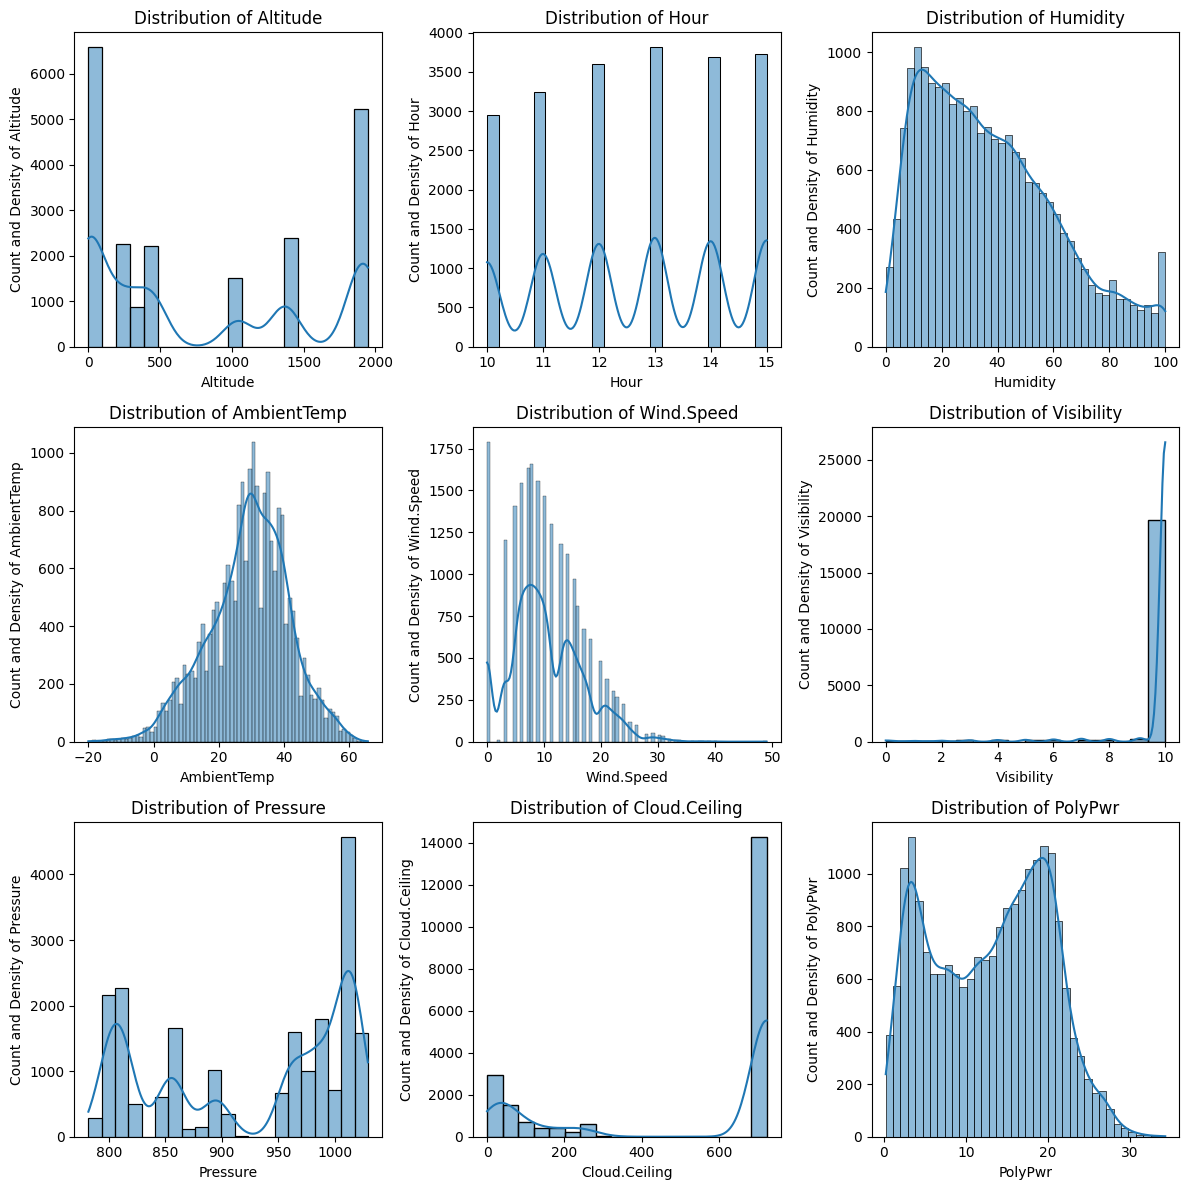

In [19]:
# Histplot with kde
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12,12))
axes = axes.flatten()

for i in range(len(nums)) :
    sns.histplot(data=df, ax=axes[i], x=nums[i], kde=True)
    axes[i].set_title(f'Distribution of {nums[i]}')
    axes[i].set_ylabel(f'Count and Density of {nums[i]}')
    axes[i].set_xlabel(f'{nums[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(nums) < len(axes) :
    axes[len(nums)].remove()

plt.tight_layout()

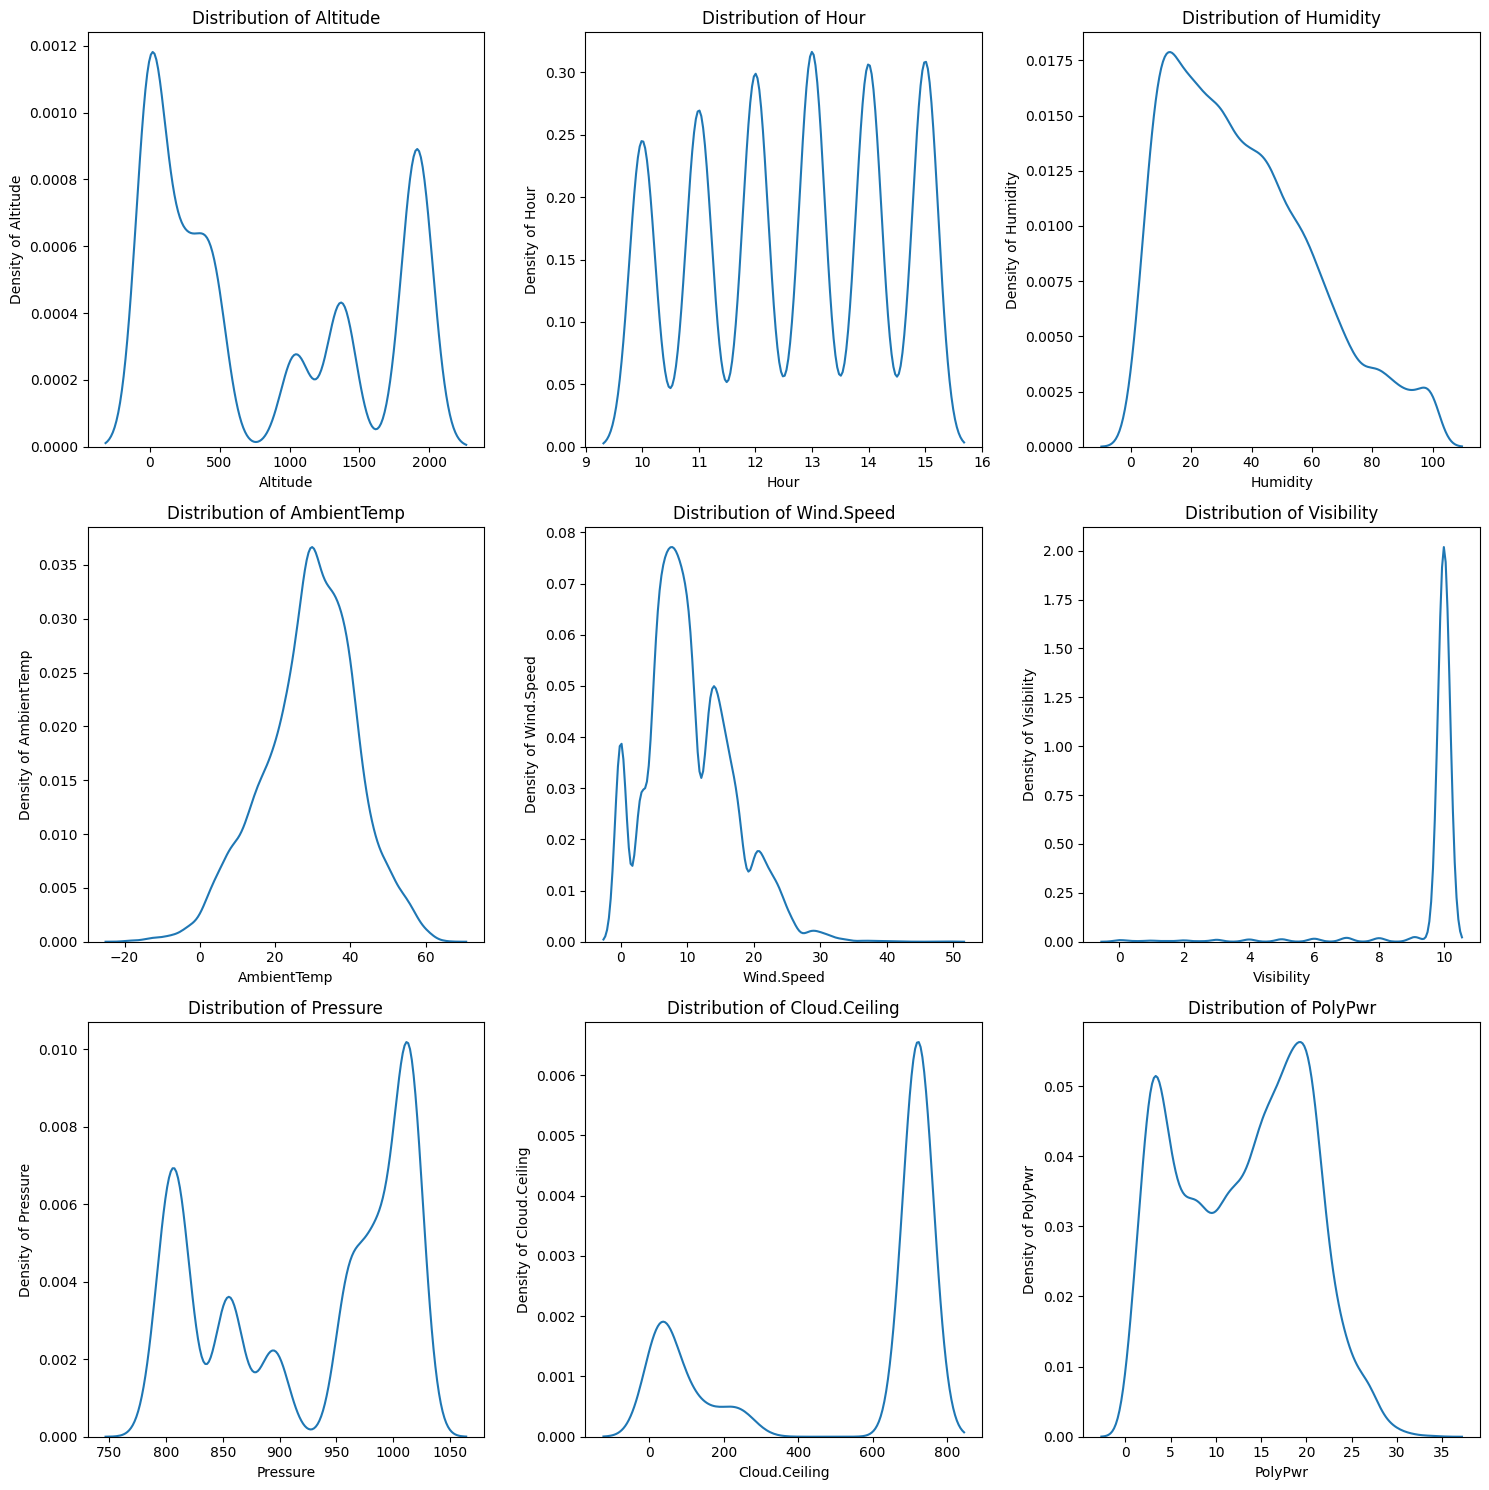

In [20]:
# Focusing only on kde
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,15))
axes = axes.flatten()

for i in range(len(nums)) :
    sns.kdeplot(data=df, ax=axes[i], x=nums[i])
    axes[i].set_title(f'Distribution of {nums[i]}')
    axes[i].set_ylabel(f'Density of {nums[i]}')
    axes[i].set_xlabel(f'{nums[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(nums) < len(axes) :
    axes[len(nums)].remove()

plt.tight_layout()

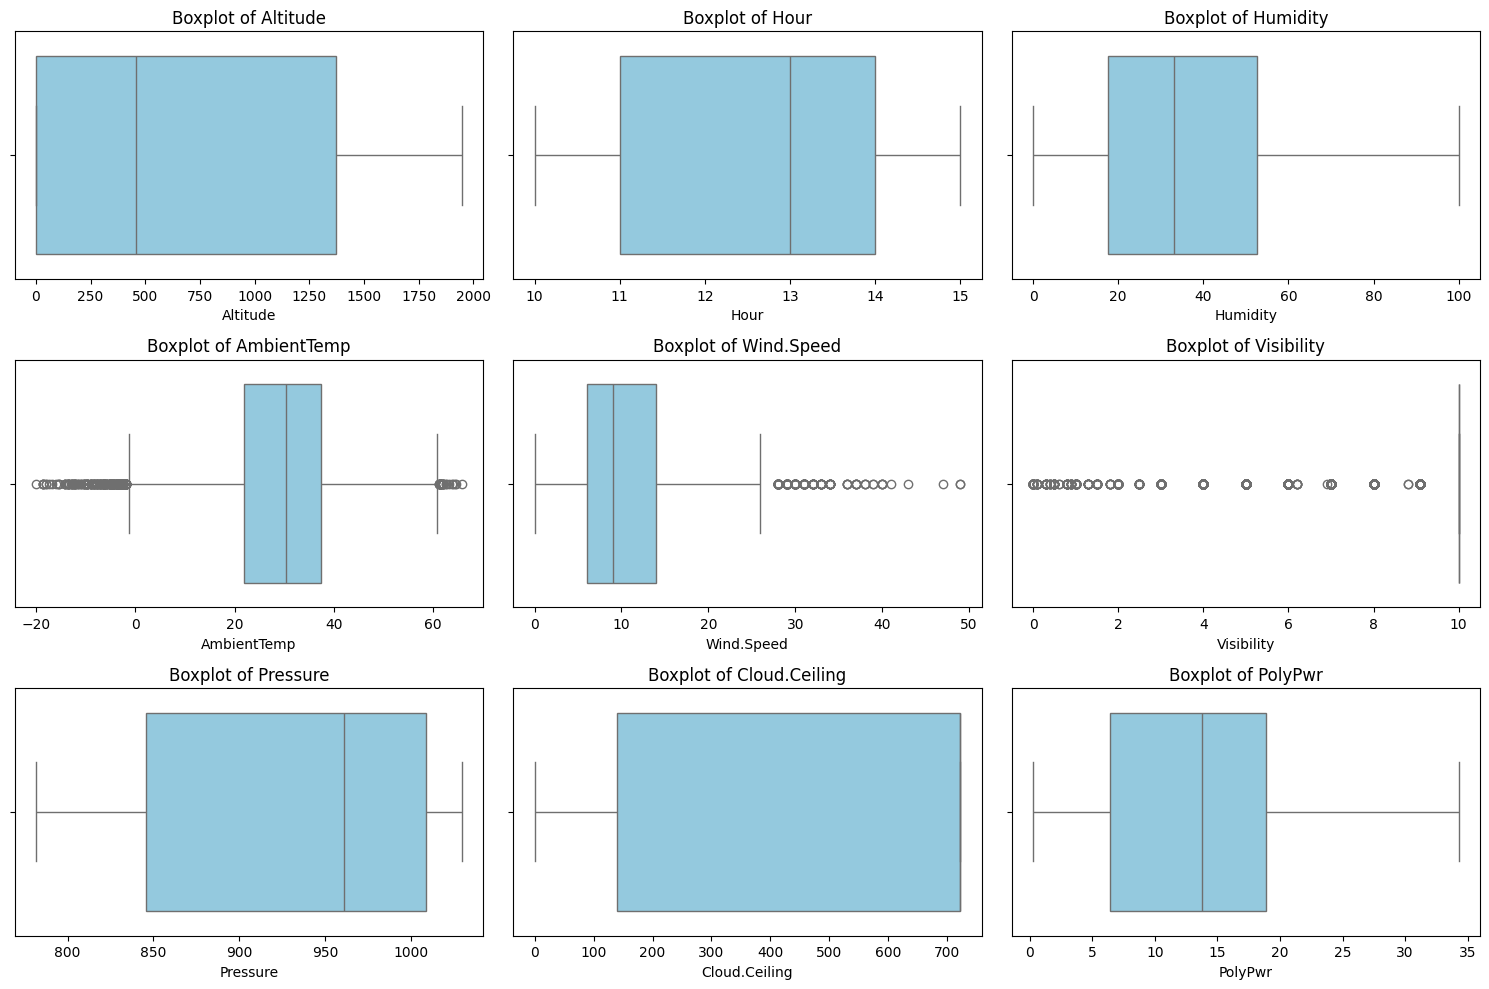

In [21]:
# Boxplot
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i in range(len(nums)) :
  sns.boxplot(data=df, ax=axes[i], x=nums[i], orient='h', color='skyblue')
  axes[i].set_title(f'Boxplot of {nums[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(nums) < len(axes):
    axes[len(nums)].remove()

plt.tight_layout()

There are not many features with outliers, only AmbientTemp, Wind.Speed, and Visibility

## Categorical Columns

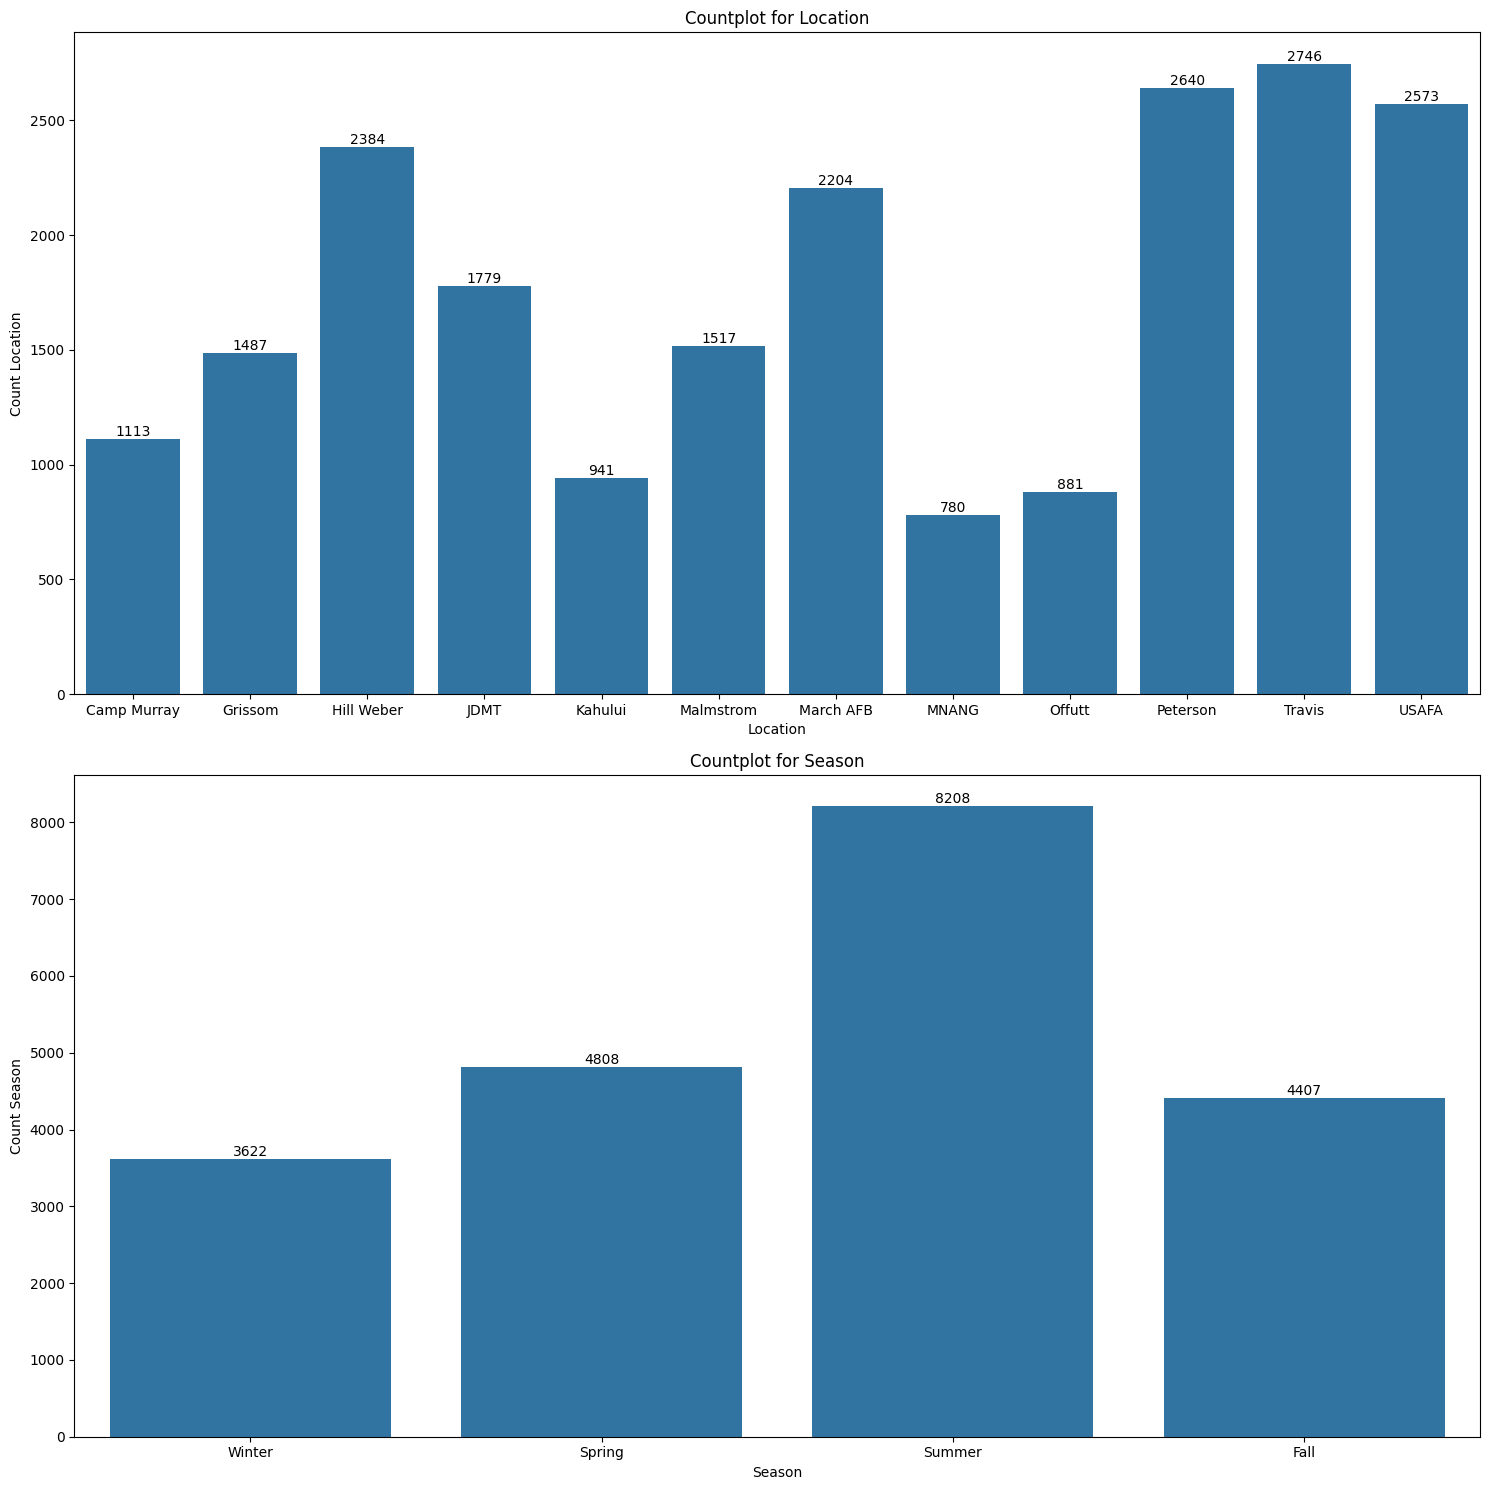

In [22]:
# Countplot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 15))

for i in range(len(cats)):
    ax = sns.countplot(data=df, ax=axes[i], x=cats[i])
    axes[i].set_title(f'Countplot for {cats[i]}')
    axes[i].set_ylabel(f'Count {cats[i]}')
    axes[i].tick_params(axis='x')
    axes[i].bar_label(axes[i].containers[0])

plt.tight_layout()
plt.show()

# Bivariate/Multivariate Analysis

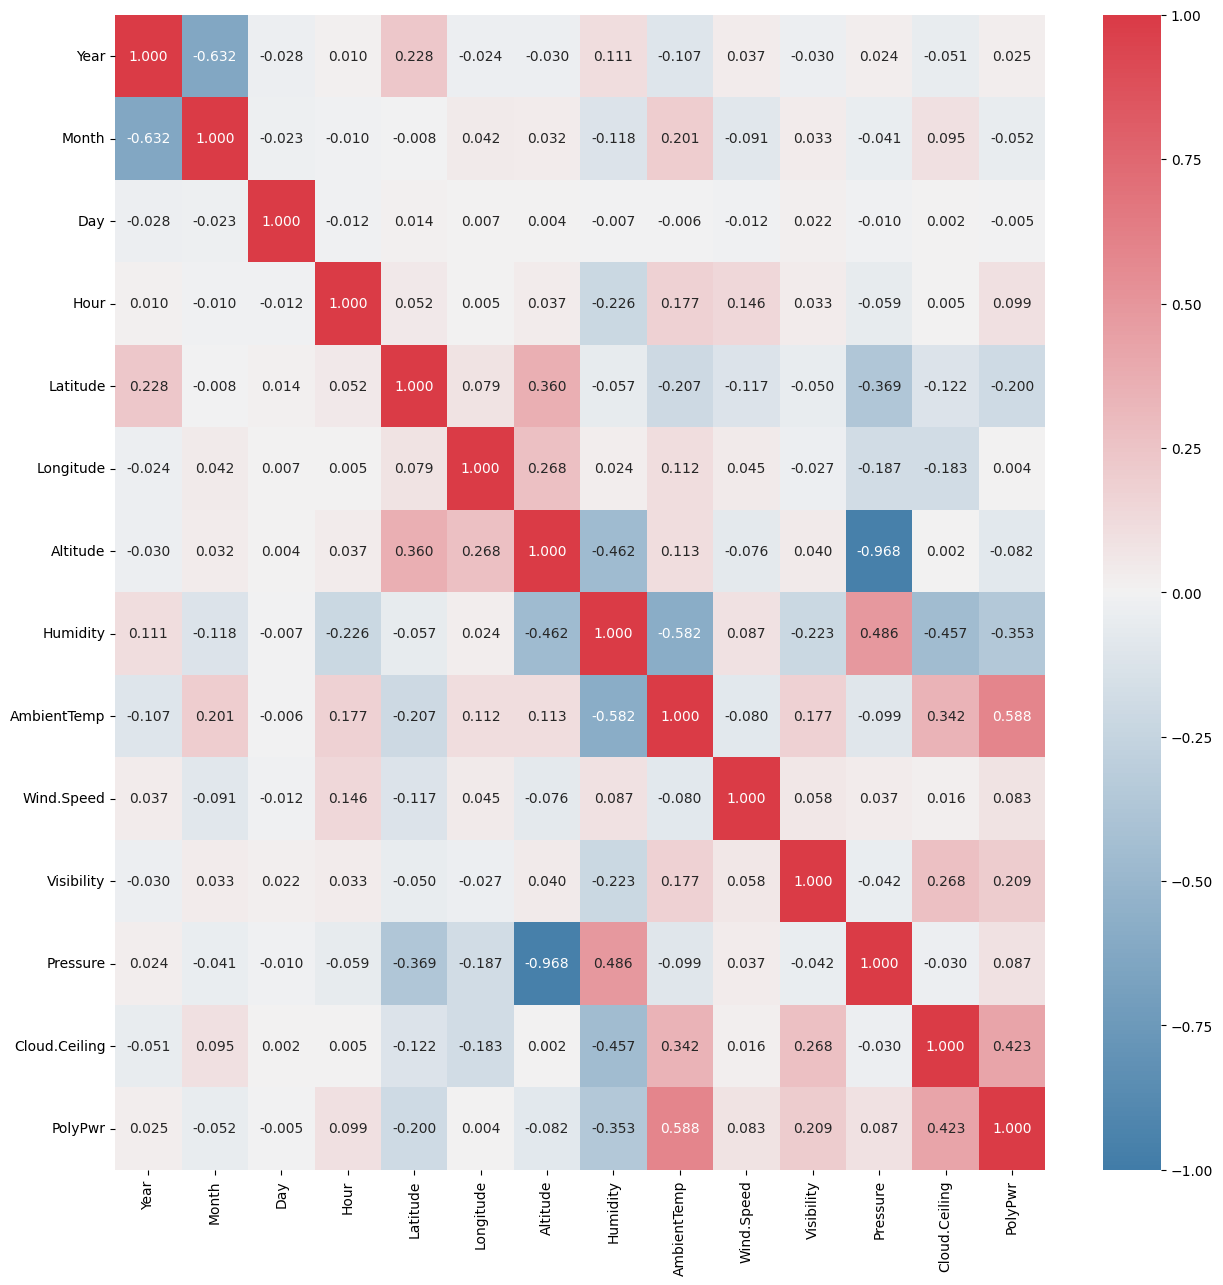

In [23]:
# Heatmap (corr spearman)
plt.figure(figsize=(15,15))
cmap_custom = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(data = df.corr(numeric_only=True, method='spearman'), cmap=cmap_custom, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.show()

In this case we use spearman correlation that is more robust/accurate in capturing non-linear (can be seen from pairplot down below) correlation of features. Some feature that have high correlation to target are Humidity, AmbientTemp, Visibility, and Cloud.Ceiling. We also likely to drop or not use Altitude feature since it has really high correlation to Pressure to avoid multicollinearity.

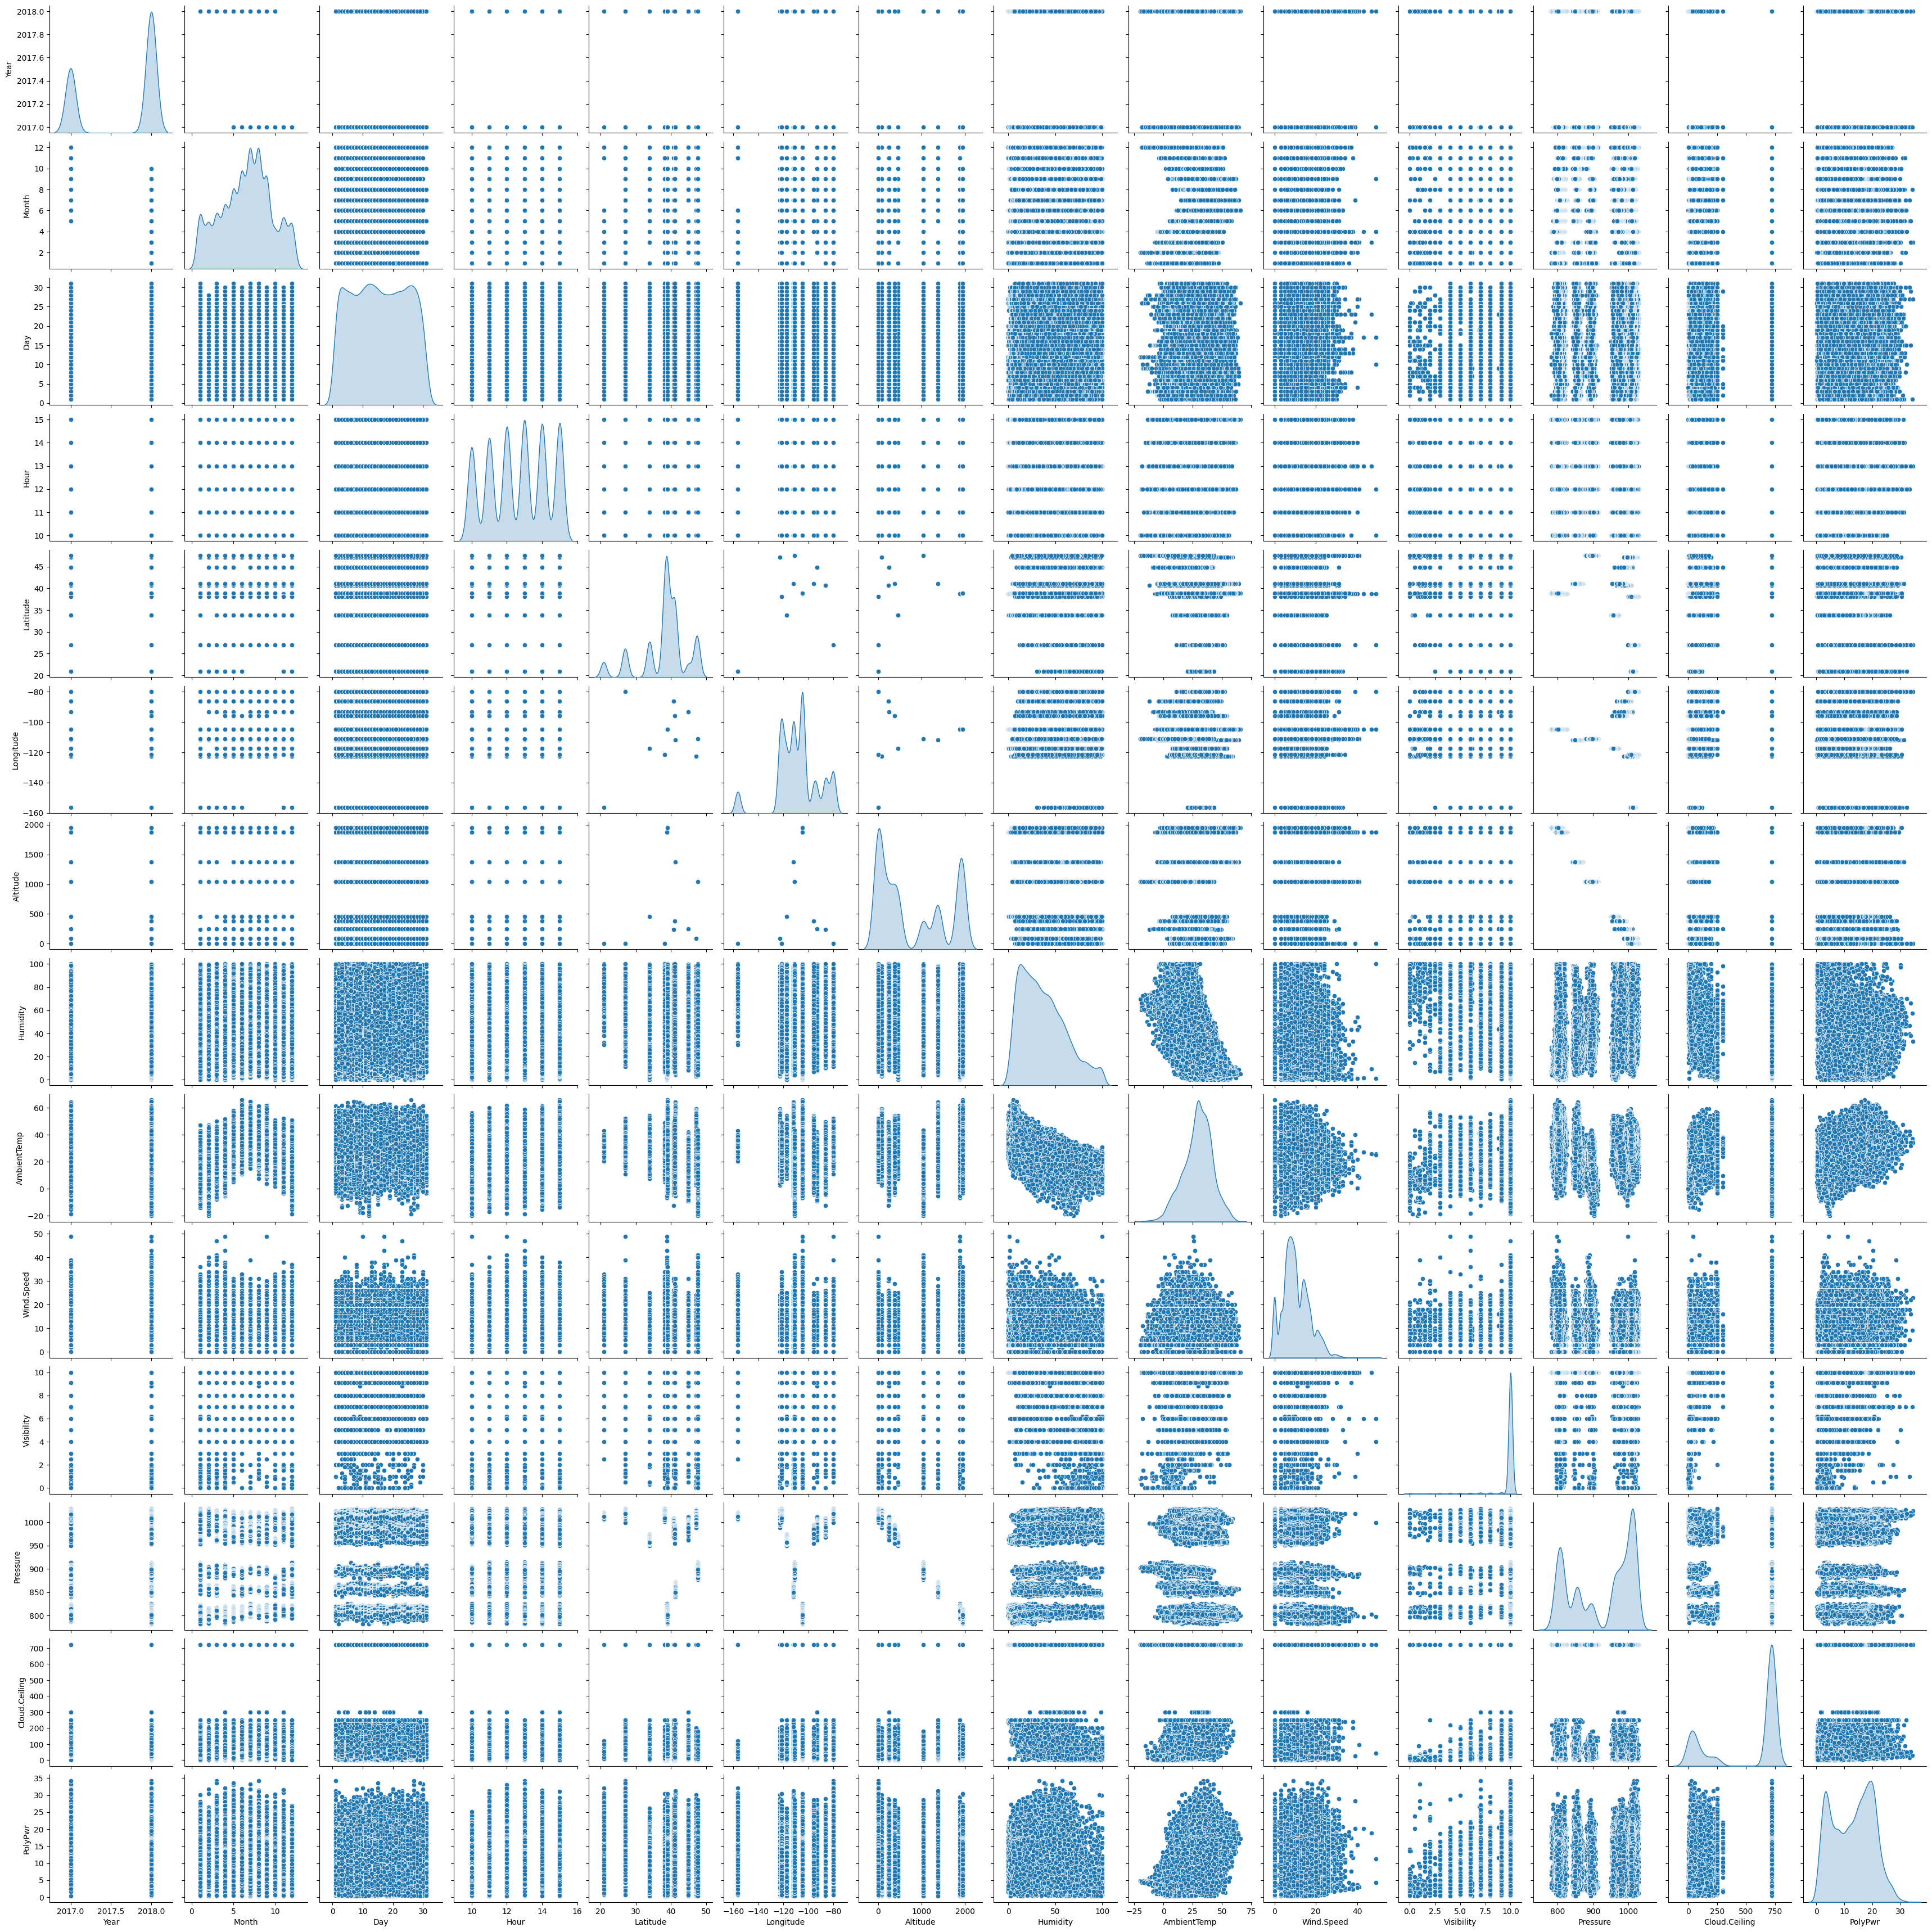

In [24]:
# Pairplot
sns.pairplot(df, diag_kind='kde')
plt.show()

The distribution of the data are mostly non-linear in this case, so later on using a robust ML technique againts non-linearity like tree-based method will probably become the choice. The preprocessing techniques will also based on this distribution.

## Location based analysis

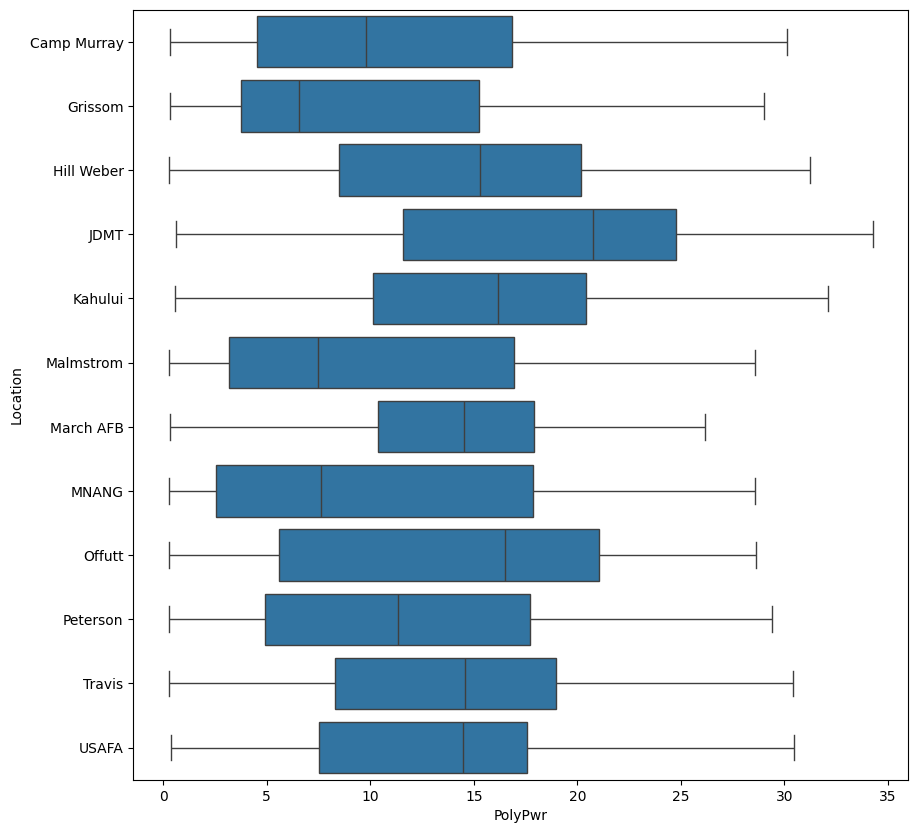

In [25]:
# Boxplot of PolyPwr by Location
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='PolyPwr', y='Location')
plt.show()

Average Solar Power by Location and Hour:
      Location  Hour    PolyPwr
22        JDMT    14  21.040531
21        JDMT    13  20.725236
20        JDMT    12  20.461270
19        JDMT    11  18.471420
26     Kahului    12  17.529915
28     Kahului    14  16.924876
27     Kahului    13  16.811872
16  Hill Weber    14  16.609368
23        JDMT    15  16.364104
15  Hill Weber    13  16.251637
52      Offutt    14  16.133708
45   March AFB    13  15.856107
25     Kahului    11  15.589097
18        JDMT    10  15.433431
53      Offutt    15  15.430490


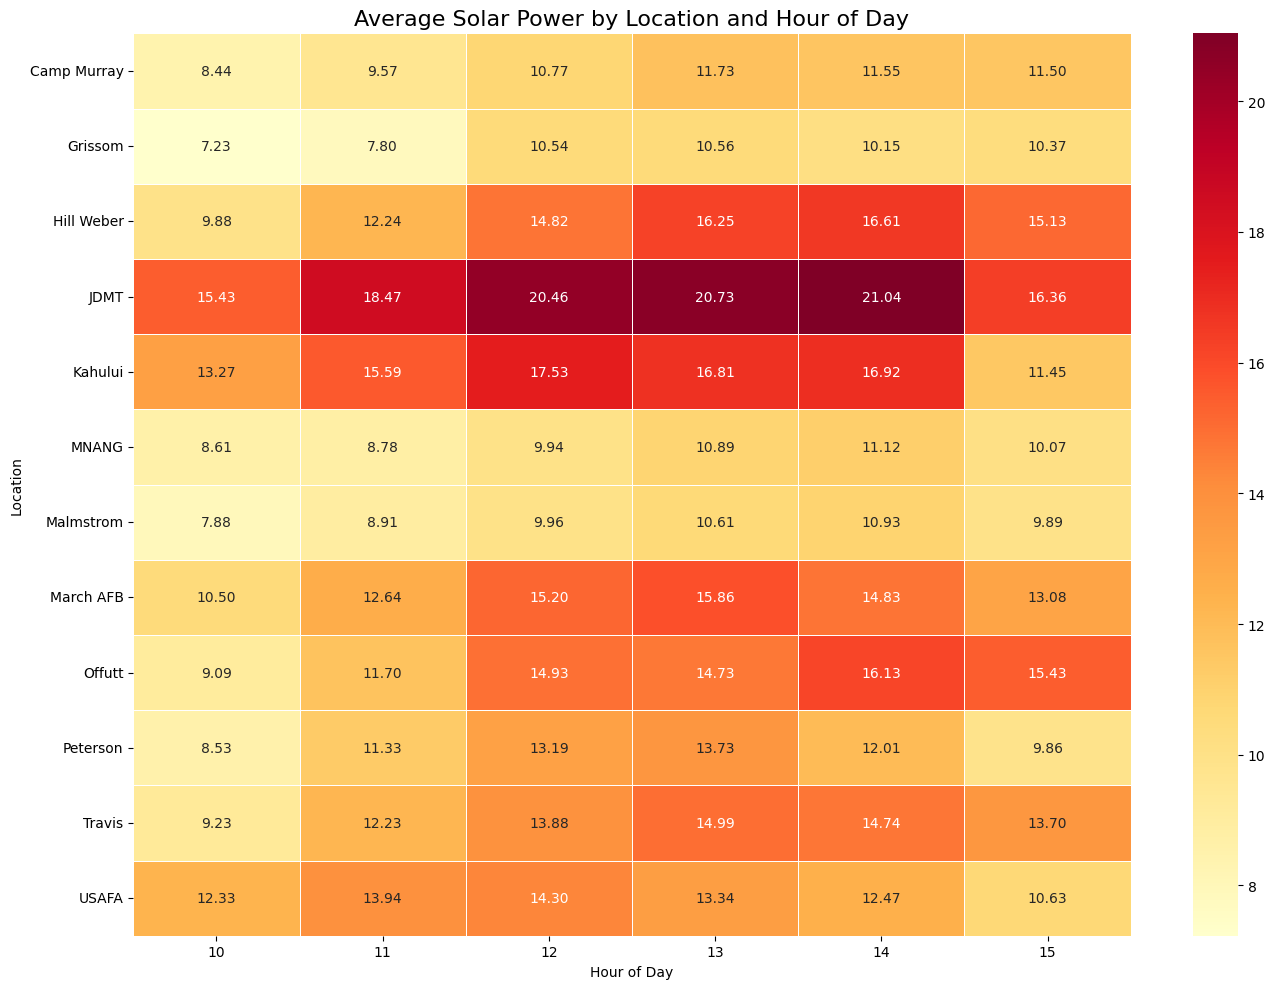

In [26]:
# Create a heatmap of average power by location and hour
location_hour_power = df.groupby(['Location', 'Hour'])['PolyPwr'].mean().reset_index()
print("Average Solar Power by Location and Hour:")
print(location_hour_power.sort_values('PolyPwr', ascending=False).head(15))

# Plot heatmap of average power by location and hour
plt.figure(figsize=(14, 10))
pivot_data = location_hour_power.pivot(index='Location', columns='Hour', values='PolyPwr')
sns.heatmap(pivot_data, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Average Solar Power by Location and Hour of Day', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

In [27]:
# # Alternative : Geographic visualization of solar power potential
# import matplotlib.pyplot as plt
# import seaborn as sns
# from mpl_toolkits.basemap import Basemap

# # Create a figure for the map
# plt.figure(figsize=(12, 8))

# # Create a basemap of the US
# m = Basemap(llcrnrlon=-130, llcrnrlat=25, urcrnrlon=-65, urcrnrlat=50,
#             projection='merc', resolution='i')
# m.drawcoastlines()
# m.drawcountries()
# m.drawstates()
# m.fillcontinents(color='lightgray', lake_color='lightblue')
# m.drawmapboundary(fill_color='lightblue')

# # Get coordinates and power data
# lats = df['Latitude'].values
# lons = df['Longitude'].values
# power = df['PolyPwr'].values

# # Convert coordinates to map projection
# x, y = m(lons, lats)

# # Create a scatter plot with power values
# scatter = m.scatter(x, y, c=power, cmap='YlOrRd', alpha=0.7, 
#                    s=200, edgecolor='k', linewidth=0.5)

# # Add a colorbar
# cbar = plt.colorbar(scatter, label='Solar Power Output (PolyPwr)')

# # Add title and labels
# plt.title('Geographic Distribution of Solar Power Potential', fontsize=16)

# plt.tight_layout()
# plt.show()

## Season based analysis

In [28]:
# Mean PolyPwr by Season
df_mean_power_season = df.groupby('Season').agg({'PolyPwr' : ['mean']})
df_mean_power_season

,PolyPwr
,mean
Season,
Fall,11.167499
Spring,14.192405
Summer,15.320546
Winter,8.263660


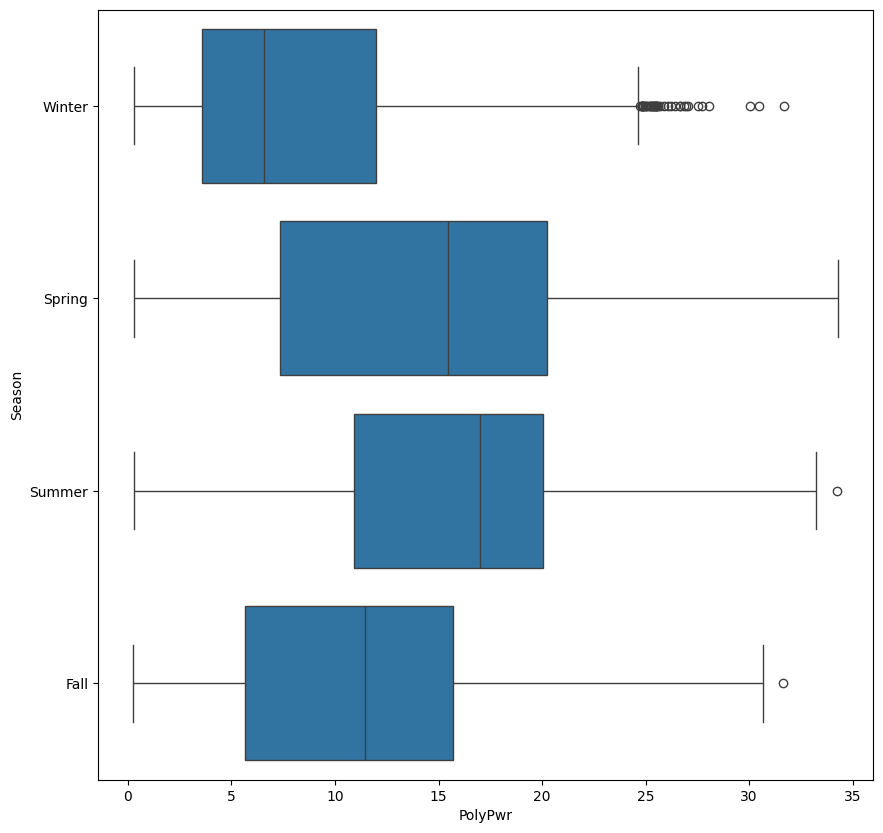

In [29]:
# Boxplot of PolyPwr by Season
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='PolyPwr', y='Season')
plt.show()

Average Solar Power by Season and Hour:
    Season  Hour    PolyPwr
15  Summer    13  17.048997
14  Summer    12  16.677715
16  Summer    14  16.109781
9   Spring    13  16.012286
8   Spring    12  15.701774
10  Spring    14  15.017158
13  Summer    11  14.790652
17  Summer    15  14.708056
7   Spring    11  13.611928
11  Spring    15  13.507577
3     Fall    13  12.857540
4     Fall    14  12.515680
2     Fall    12  12.104081
12  Summer    10  12.090137
6   Spring    10  10.844206


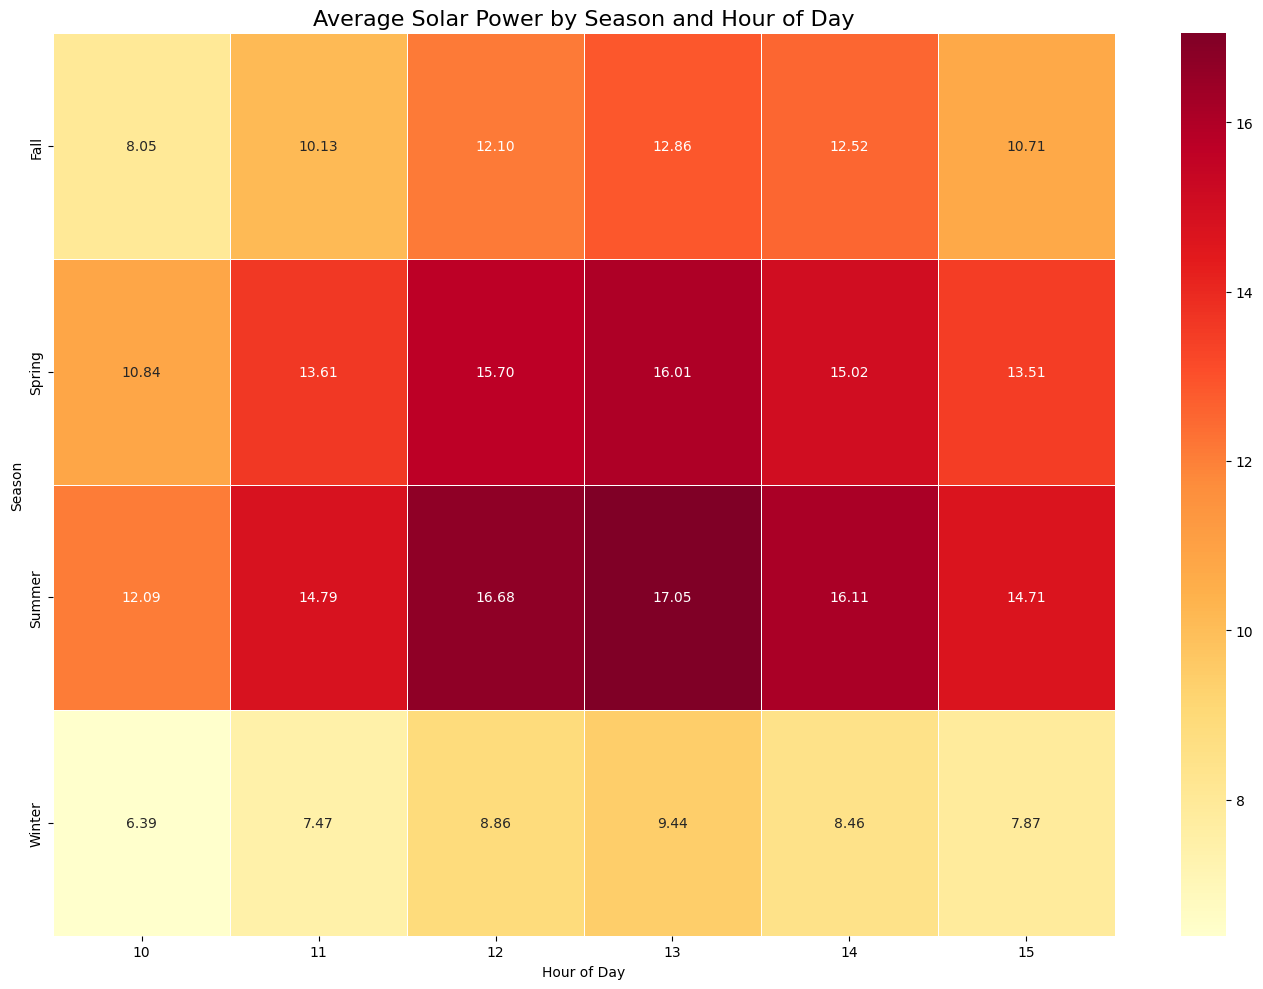

In [30]:
# Create a heatmap of average power by location and hour
season_hour_power = df.groupby(['Season', 'Hour'])['PolyPwr'].mean().reset_index()
print("Average Solar Power by Season and Hour:")
print(season_hour_power.sort_values('PolyPwr', ascending=False).head(15))

# Plot heatmap of average power by location and hour
plt.figure(figsize=(14, 10))
pivot_data = season_hour_power.pivot(index='Season', columns='Hour', values='PolyPwr')
sns.heatmap(pivot_data, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Average Solar Power by Season and Hour of Day', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Season')
plt.tight_layout()
plt.show()

Summer as expected have the highest median PolyPwr with the lowest variability and highest overall mean of PolyPwr from all season.

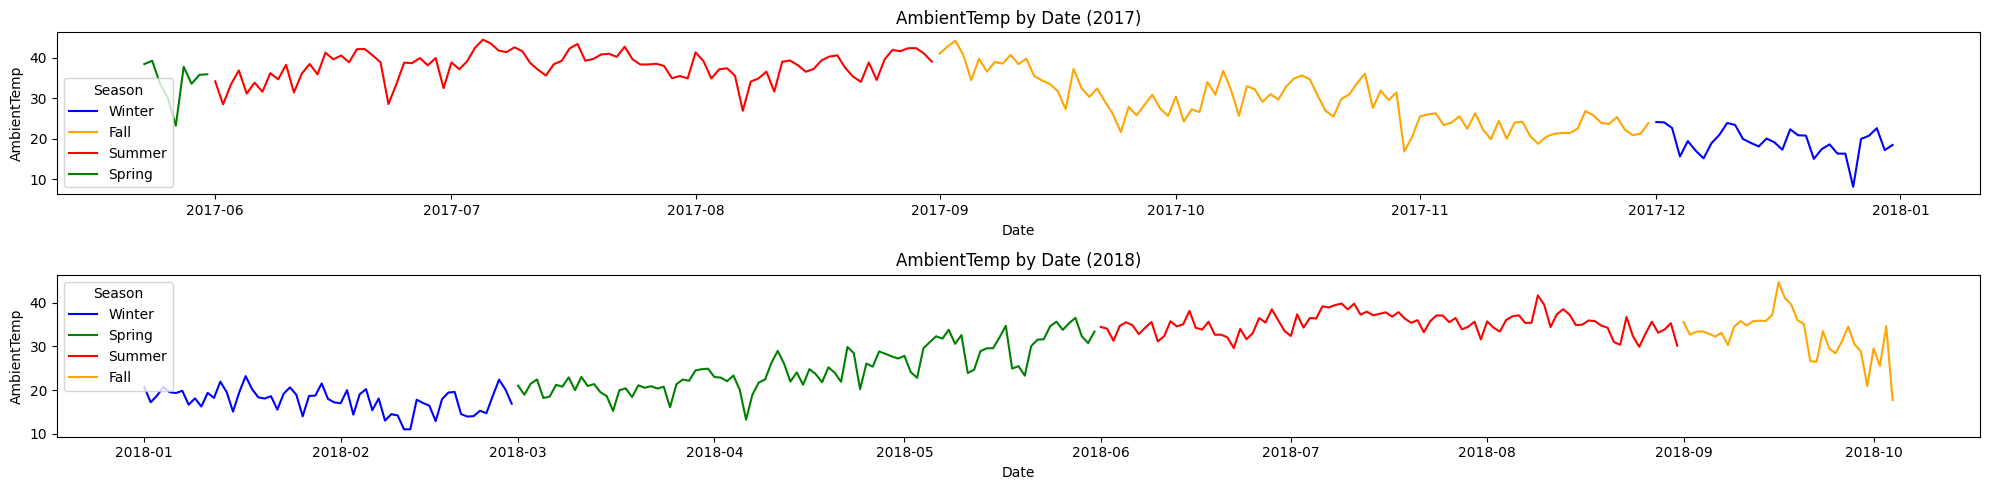

In [31]:
# AmbientTemp by Date per Season
df_year_2017 = df.loc[df['Year'] == 2017, :]
df_year_2018 = df.loc[df['Year'] == 2018, :]

# Define consistent colors for each season
season_colors = {
    'Winter': 'blue',
    'Spring': 'green',
    'Summer': 'red',
    'Fall': 'orange'
}

fig, ax = plt.subplots(2, 1, figsize=(20, 5))

# Plot for 2017
sns.lineplot(data=df_year_2017, x='Date', y='AmbientTemp', hue='Season', palette=season_colors, ci=None, ax=ax[0])
ax[0].set_ylabel('AmbientTemp')
ax[0].set_xlabel('Date')
ax[0].set_title('AmbientTemp by Date (2017)')

# # Set x-axis limits for 2017 (from beginning to end of year)
# ax[0].set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2017-12-31'))

# Plot for 2018
sns.lineplot(data=df_year_2018, x='Date', y='AmbientTemp', hue='Season', palette=season_colors, ci=None, ax=ax[1])
ax[1].set_ylabel('AmbientTemp')
ax[1].set_xlabel('Date')
ax[1].set_title('AmbientTemp by Date (2018)')

# # Set x-axis limits for 2018 (from beginning to end of year)
# ax[1].set_xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2018-12-31'))

plt.tight_layout()
plt.show()

The ambient temperature does kinda have the same trend with PolyPwr generated where it went down during Winter which also explains their correlation.

# Pre-Processing & Feature Engineering

In [32]:
# Make a copy of original dataframe for preprocessing and encoding process
df_encoding = df.copy()
df_encoding.sample(5)

,Datetime,Date,Time,Year,Month,Day,Hour,Location,Latitude,Longitude,Altitude,Season,Humidity,AmbientTemp,Wind.Speed,Visibility,Pressure,Cloud.Ceiling,PolyPwr
15773,2017-06-16 10:00:00,2017-06-16,10:00,2017,6,16,10,Travis,38.16,-121.56,1,Summer,32.94067,35.41771,0,7.0,1011.9,722,15.81319
4520,2018-07-03 13:00:00,2018-07-03,13:00,2018,7,3,13,Hill Weber,41.15,-111.99,1370,Summer,59.06372,23.84132,21,10.0,852.8,60,6.29971
3125,2017-09-15 15:15:00,2017-09-15,15:15,2017,9,15,15,Hill Weber,41.15,-111.99,1370,Fall,21.40503,31.55304,17,10.0,850.5,50,21.01634
10969,2018-06-29 12:00:00,2018-06-29,12:00,2018,6,29,12,March AFB,33.90,-117.26,458,Summer,24.67041,35.46806,3,10.0,958.5,722,19.52496
19085,2017-08-13 10:00:00,2017-08-13,10:00,2017,8,13,10,USAFA,38.95,-104.83,1947,Summer,34.00269,29.08569,5,10.0,800.9,722,12.74344


In [33]:
# Drop features that are irrelevant and we will not use for this modelling case
# Keep Month, Day, and Hour as they contain valuable temporal information for solar power prediction
df_encoding = df_encoding.drop(columns=['Datetime', 'Date', 'Time', 'Latitude', 'Longitude', 'Altitude', 'Year'])

In [34]:
# One-hot encoding for Location and Season
one_hot_encoded_cols = ['Location', 'Season']

for col in one_hot_encoded_cols:
    onehots = pd.get_dummies(df_encoding[col], prefix=col, drop_first=True, sparse=False) * 1
    df_encoding = pd.concat([df_encoding, onehots], axis=1)

# Drop the original columns after one-hot encoding
df_encoding.drop(columns=one_hot_encoded_cols, axis=1, inplace=True)

In [35]:
# Check dataframe after encoding and drop irrelevant features
df_encoding

,Month,Day,Hour,Humidity,AmbientTemp,Wind.Speed,Visibility,Pressure,Cloud.Ceiling,PolyPwr,Location_Grissom,Location_Hill Weber,Location_JDMT,Location_Kahului,Location_MNANG,Location_Malmstrom,Location_March AFB,Location_Offutt,Location_Peterson,Location_Travis,Location_USAFA,Season_Spring,Season_Summer,Season_Winter
0,12,3,11,81.71997,12.86919,5,10.0,1010.6,722,2.42769,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,12,3,13,96.64917,9.66415,0,10.0,1011.3,23,2.46273,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,12,3,13,93.61572,15.44983,5,10.0,1011.6,32,4.46836,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,12,4,12,77.21558,10.36659,5,2.0,1024.4,6,1.65364,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,12,4,14,54.80347,16.85471,3,3.0,1023.7,9,6.57939,0,0,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21040,9,28,15,11.66992,43.22510,14,10.0,802.3,722,9.79611,0,0,0,0,0,0,0,0,0,0,1,0,0,0
21041,9,29,13,18.22510,28.98247,13,10.0,799.2,722,10.88992,0,0,0,0,0,0,0,0,0,0,1,0,0,0
21042,9,29,14,15.52124,33.49167,10,10.0,798.4,722,8.24479,0,0,0,0,0,0,0,0,0,0,1,0,0,0
21043,9,29,15,6.63452,51.62163,10,10.0,797.8,722,12.47328,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [36]:
# Re-arrange the columns (PolyPwr in last)
rearranged_col = [col for col in df_encoding.columns if col != 'PolyPwr'] + target_col
df_encoding = df_encoding[rearranged_col]

# Feature Selection

At first we will just use all the features that we got after pre-processing, this part is just additional check to compare the result of df.corr() with SelectKbest to see what will best features for prediction later

### Checking correlation heatmap (spearmann method)

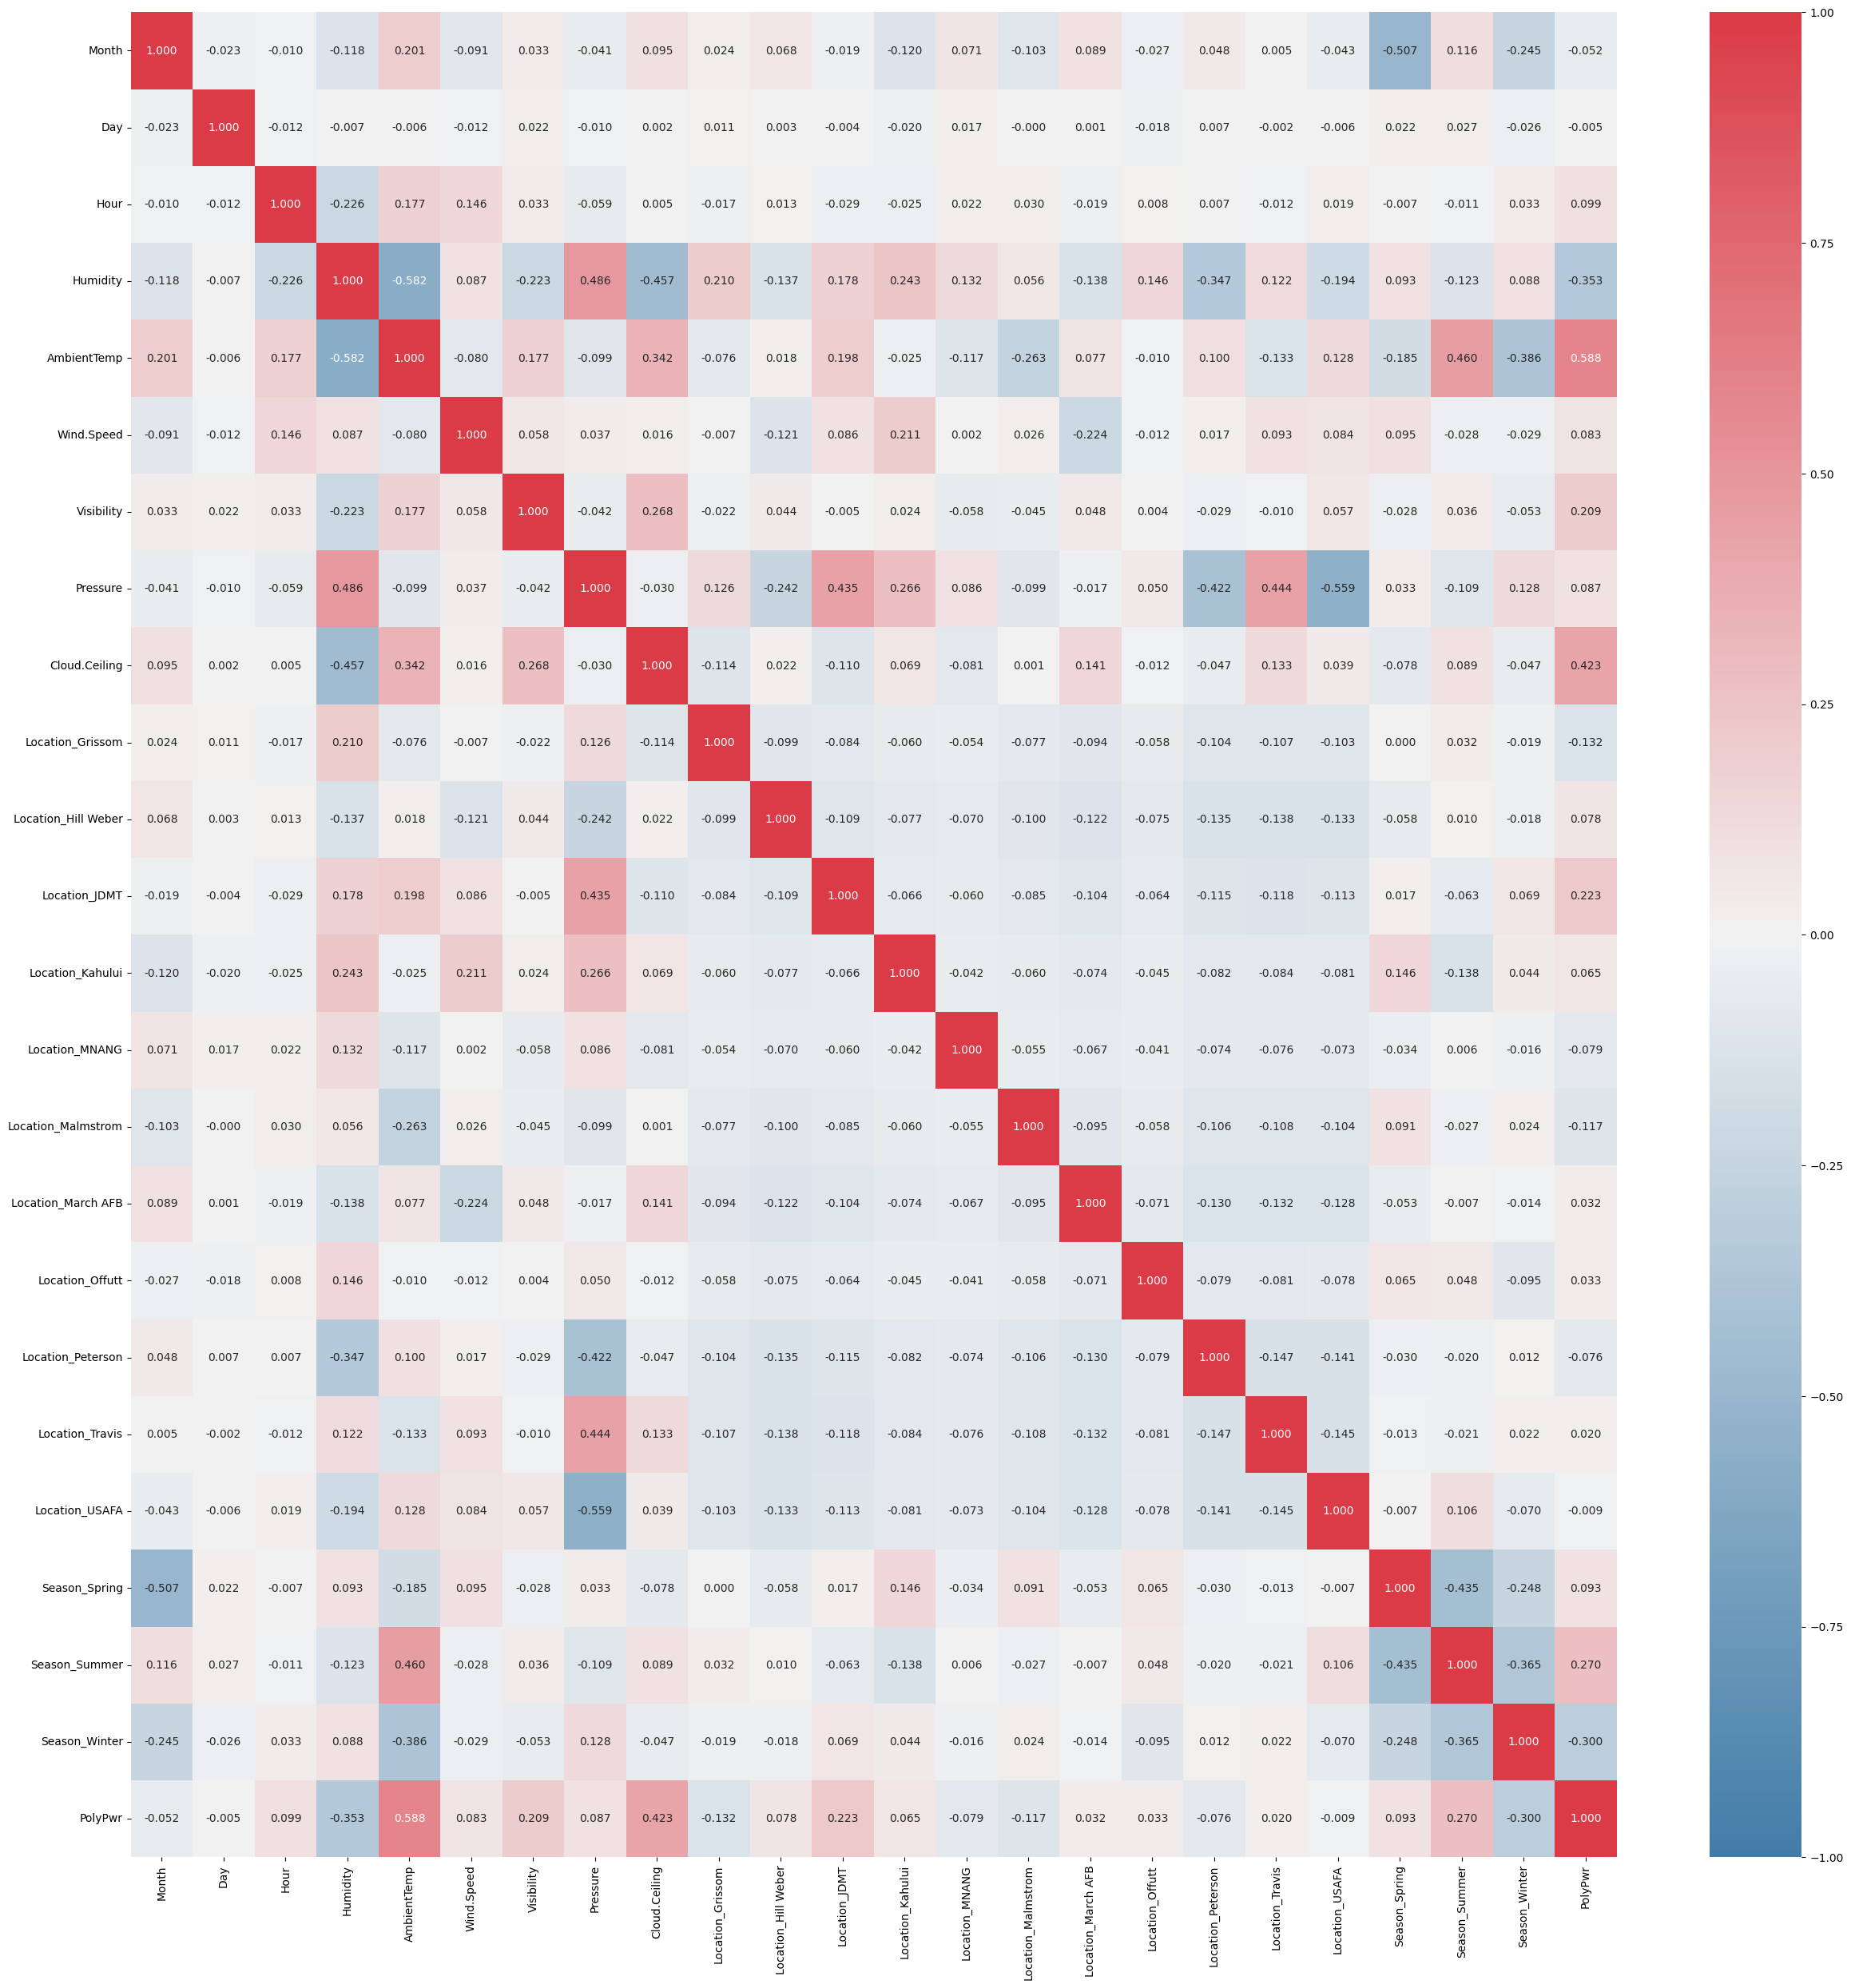

In [37]:
# Heatmap (corr spearman)
plt.figure(figsize=(30,30))
cmap_custom = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(data = df_encoding.corr(numeric_only=True, method='spearman'), cmap=cmap_custom, annot=True, fmt='.3f', vmin=-1, vmax=1)
plt.show()

In [40]:
# Correlation analysis in tabluar form
def calculate_correlation_tabular(df, target_col, method='spearman', corr_type='feature_feature'):
    """
    Calculate and display correlation analysis in tabular form for feature-to-feature,
    feature-to-target correlations, or both.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the features and target variable
    target_col : str
        Name of the target column in the DataFrame
    method : str, optional (default='spearman')
        Correlation method to use. Options include:
        - 'pearson': standard correlation coefficient
        - 'spearman': Spearman rank correlation
        - 'kendall': Kendall Tau correlation coefficient
    corr_type : str, optional (default='feature_feature')
        Type of correlation analysis to perform:
        - 'feature_feature': correlations between all features
        - 'feature_target': correlations between features and target variable
        - 'both': display both feature-feature and feature-target correlations

    Returns:
    --------
    tuple or pandas.DataFrame
        If corr_type is 'both':
            Returns a tuple (feature_feature_df, feature_target_df)
        Otherwise:
            Returns a single DataFrame containing the correlation analysis results
            
        DataFrame columns for feature_feature:
            - 'A': First feature name
            - 'B': Second feature name
            - 'Corr Value': Absolute correlation value
            - 'Corr Type': 'Positive' or 'Negative'
        DataFrame columns for feature_target:
            - 'Feature': Feature name
            - 'Corr Value': Absolute correlation value
            - 'Corr Type': 'Positive' or 'Negative'

    Raises:
    -------
    ValueError
        If corr_type is not 'feature_feature', 'feature_target', or 'both'
    """
    
    # Input validation for correlation type
    if corr_type not in ['feature_feature', 'feature_target', 'both']:
        raise ValueError("corr_type must be either 'feature_feature', 'feature_target', or 'both'")
    
    def get_feature_feature_corr():
        """
        Helper function to calculate feature-to-feature correlations
        """
        # Calculate correlation matrix for all numeric columns
        corr_feature = df.corr(method=method, numeric_only=True)

        # Convert correlation matrix to long format for better visualization
        flat_cm = corr_feature.stack().reset_index()
        flat_cm.columns = ['A', 'B', 'Corr Value']

        # Apply filters to remove:
        # 1. Self-correlations (A to A)
        # 2. Target variable correlations
        # 3. Duplicate pairs (A-B vs B-A)
        flat_cm = flat_cm.loc[
            (flat_cm['A'] != flat_cm['B']) &  # Remove self-correlations
            (flat_cm['A'] != target_col) &     # Remove target from first column
            (flat_cm['B'] != target_col)       # Remove target from second column
        ]

        # Add correlation type (Positive/Negative) and convert to absolute values
        flat_cm['Corr Type'] = flat_cm['Corr Value'].apply(lambda x: 'Positive' if x >= 0 else 'Negative')
        flat_cm['Corr Value'] = flat_cm['Corr Value'].abs()
        
        # Sort by correlation strength and remove duplicates
        flat_cm = flat_cm.sort_values(by='Corr Value', ascending=False, ignore_index=True)
        redundan_cm = flat_cm.drop_duplicates(subset=['Corr Value', 'Corr Type']).reset_index(drop=True)
        
        print("Correlation Between Features:")
        display(redundan_cm.iloc[:15].reset_index(drop=True))
        return redundan_cm
    
    def get_feature_target_corr():
        """
        Helper function to calculate feature-to-target correlations
        """
        # Calculate correlations between all features and the target variable
        corr_target = df.corrwith(df[target_col], method=method, numeric_only=True)
        
        # Convert to DataFrame for better manipulation
        corr_final = corr_target.reset_index(name='Corr Value').rename(columns={'index': 'Feature'})

        # Remove target variable self-correlation
        corr_final = corr_final.loc[corr_final['Feature'] != target_col]

        # Add correlation type and convert to absolute values
        corr_final['Corr Type'] = corr_final['Corr Value'].apply(lambda x: 'Positive' if x >= 0 else 'Negative')
        corr_final['Corr Value'] = corr_final['Corr Value'].abs()
        
        # Sort by correlation strength
        corr_final = corr_final.sort_values('Corr Value', ascending=False, ignore_index=True)

        print("\nCorrelation of Features to Target:")
        display(corr_final.iloc[:15].reset_index(drop=True))
        return corr_final
    
    # Handle different correlation type requests
    if corr_type == 'feature_feature':
        return get_feature_feature_corr()
    elif corr_type == 'feature_target':
        return get_feature_target_corr()
    else:  # corr_type == 'both'
        # Calculate and return both types of correlations
        feature_feature_df = get_feature_feature_corr()
        feature_target_df = get_feature_target_corr()
        return feature_feature_df, feature_target_df

In [41]:
# Correlation analysis for both feature-feature and feature-target
ff_corr, ft_corr = calculate_correlation_tabular(df, target_col='PolyPwr', corr_type='both')

Correlation Between Features:


,A,B,Corr Value,Corr Type
0,Pressure,Altitude,0.967903,Negative
1,Year,Month,0.631658,Negative
2,AmbientTemp,Humidity,0.581557,Negative
3,Pressure,Humidity,0.486175,Positive
4,Humidity,Altitude,0.462497,Negative
5,Humidity,Cloud.Ceiling,0.457360,Negative
6,Latitude,Pressure,0.369194,Negative
7,Altitude,Latitude,0.360111,Positive
8,AmbientTemp,Cloud.Ceiling,0.342157,Positive
9,Altitude,Longitude,0.267914,Positive



Correlation of Features to Target:


,Feature,Corr Value,Corr Type
0,AmbientTemp,0.587660,Positive
1,Cloud.Ceiling,0.423284,Positive
2,Humidity,0.353289,Negative
3,Visibility,0.208654,Positive
4,Latitude,0.200234,Negative
5,Hour,0.099473,Positive
6,Pressure,0.086960,Positive
7,Wind.Speed,0.082883,Positive
8,Altitude,0.082454,Negative
9,Month,0.052424,Negative


As for the features with low correlation to target will potentially be dropped and also all of the features generated from one-hot encoding method will have to be used if one of them have medium-high corr to target.

### Checking feature importance using SelectKBest (Mutual information, Chi2, and ANOVA F-test)

In [38]:
# Create temporary dataframe for testing SelectKBest
df_feature_target_relation = df_encoding.copy()
df_feature_target_relation.head()

,Month,Day,Hour,Humidity,AmbientTemp,Wind.Speed,Visibility,Pressure,Cloud.Ceiling,Location_Grissom,Location_Hill Weber,Location_JDMT,Location_Kahului,Location_MNANG,Location_Malmstrom,Location_March AFB,Location_Offutt,Location_Peterson,Location_Travis,Location_USAFA,Season_Spring,Season_Summer,Season_Winter,PolyPwr
0,12,3,11,81.71997,12.86919,5,10.0,1010.6,722,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2.42769
1,12,3,13,96.64917,9.66415,0,10.0,1011.3,23,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2.46273
2,12,3,13,93.61572,15.44983,5,10.0,1011.6,32,0,0,0,0,0,0,0,0,0,0,0,0,0,1,4.46836
3,12,4,12,77.21558,10.36659,5,2.0,1024.4,6,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.65364
4,12,4,14,54.80347,16.85471,3,3.0,1023.7,9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,6.57939


In [39]:
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif,
    f_classif,
    chi2,
    f_regression,
    mutual_info_regression
)

# Calculate feature importance scores using different statistical methods for classification or regression
def calculate_feature_importance(X, y, task='classification', method='mutual_info', k='all'):
    """
    Calculate feature importance scores using different statistical methods for classification or regression.

    Parameters:
    X (DataFrame): Feature matrix
    y (Series): Target variable
    task (str): Task type ('classification' or 'regression')
    method (str): Method for feature selection ('mutual_info', 'anova', 'chi2' for classification; 'f_regression', 'mutual_info' for regression)
    k (int or 'all'): Number of top features to select. Use 'all' to see scores for all features.

    Returns:
    DataFrame: Sorted DataFrame with feature names, scores, and p-values (if applicable)
    """
    # Select the appropriate scoring function based on task and method
    if task == 'classification':
        if method == 'mutual_info':
            score_func = mutual_info_classif
        elif method == 'anova':
            score_func = f_classif
        elif method == 'chi2':
            score_func = chi2
        else:
            raise ValueError("For classification, method must be 'mutual_info', 'anova', or 'chi2'")
    elif task == 'regression':
        if method == 'f_regression':
            score_func = f_regression
        elif method == 'mutual_info':
            score_func = mutual_info_regression
        else:
            raise ValueError("For regression, method must be 'f_regression' or 'mutual_info'")
    else:
        raise ValueError("Task must be 'classification' or 'regression'")

    # Instantiate SelectKBest with the chosen scoring function
    k_best = SelectKBest(score_func=score_func, k=k)

    # Fit the model and transform the data
    k_best.fit_transform(X, y)

    # Extract feature scores and names
    feature_scores = k_best.scores_
    feature_names = X.columns

    # Create a DataFrame to display feature scores
    # Note: p-values are not applicable for mutual_info_classif or mutual_info_regression, hence set to None
    feature_scores_df = pd.DataFrame({
        'Feature': feature_names,
        'Score': feature_scores,
        'P_Values': k_best.pvalues_ if method in ['anova', 'chi2', 'f_regression'] else [None] * len(feature_scores)
    })

    # Sort the DataFrame by scores in descending order
    feature_scores_df = feature_scores_df.sort_values(by='Score', ascending=False)

    return feature_scores_df

In [44]:
# Function implementation (this case is for classification)
x_features_test = df_feature_target_relation.drop(columns=['PolyPwr'])  # Features
y_target_test = df_feature_target_relation['PolyPwr']  # Target variable

# Calculate feature importance using mutual information
mi_scores_df = calculate_feature_importance(x_features_test, y_target_test, task='regression', method='mutual_info')
print("Mutual Information: ")
display(mi_scores_df.iloc[:15].reset_index(drop=True))

# Calculate feature importance using f-regression
f_scores_df = calculate_feature_importance(x_features_test, y_target_test, task='regression', method='f_regression')
print("F-regression test: ")
display(f_scores_df.iloc[:15].reset_index(drop=True))

# Bring back the correlation using Spearman for comparison
print("Spearman Correlation :")
ft_corr = calculate_correlation_tabular(df_encoding, target_col='PolyPwr', corr_type='feature_target')

Mutual Information: 


,Feature,Score,P_Values
0,AmbientTemp,0.296731,None
1,Pressure,0.202012,None
2,Month,0.193104,None
3,Cloud.Ceiling,0.163956,None
4,Humidity,0.161570,None
5,Season_Winter,0.091655,None
6,Season_Summer,0.073846,None
7,Location_Malmstrom,0.066525,None
8,Location_JDMT,0.062553,None
9,Hour,0.061735,None


F-regression test: 


,Feature,Score,P_Values
0,AmbientTemp,10689.260625,0.000000e+00
1,Cloud.Ceiling,4418.425112,0.000000e+00
2,Humidity,3956.409095,0.000000e+00
3,Season_Winter,2108.733582,0.000000e+00
4,Season_Summer,1562.467767,0.000000e+00
5,Location_JDMT,1271.509131,1.895369e-270
6,Visibility,922.234974,2.702527e-198
7,Location_Grissom,405.597165,2.315870e-89
8,Location_Malmstrom,312.709644,1.785476e-69
9,Hour,191.376996,2.463556e-43


Spearman Correlation :

Correlation of Features to Target:


,Feature,Corr Value,Corr Type
0,AmbientTemp,0.587660,Positive
1,Cloud.Ceiling,0.423284,Positive
2,Humidity,0.353289,Negative
3,Season_Winter,0.299770,Negative
4,Season_Summer,0.270045,Positive
5,Location_JDMT,0.223318,Positive
6,Visibility,0.208654,Positive
7,Location_Grissom,0.132354,Negative
8,Location_Malmstrom,0.117156,Negative
9,Hour,0.099473,Positive


As we can see that AmbientTemp still hold as the most important feature to target similar to what we got before, but interestingly the `Pressure` feature score is high in mutual_information method, this is different from what we got using df.corr(), we will analyze the result further in the modelling process.

In [75]:
# Check the available columns
df_encoding.columns

Index(['Month', 'Day', 'Hour', 'Humidity', 'AmbientTemp', 'Wind.Speed',
       'Visibility', 'Pressure', 'Cloud.Ceiling', 'Location_Grissom',
       'Location_Hill Weber', 'Location_JDMT', 'Location_Kahului',
       'Location_MNANG', 'Location_Malmstrom', 'Location_March AFB',
       'Location_Offutt', 'Location_Peterson', 'Location_Travis',
       'Location_USAFA', 'Season_Spring', 'Season_Summer', 'Season_Winter',
       'PolyPwr'],
      dtype='object')

Seeing the statistical analysis from before, we probably will approach this by not using the location encoded columns. And also as for the time component, we will only be using the `month` component since it is high enough in spearmann correlation, but we will try to experiment by adding `hour` component also.

In [76]:
# Select only relevant features
df_model = df_encoding.copy()

selected_features = ['AmbientTemp', 'Pressure', 'Cloud.Ceiling', 'Humidity', 'Hour', 'Month', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'PolyPwr']
df_model = df_model[selected_features]
df_model.sample(5)

,AmbientTemp,Pressure,Cloud.Ceiling,Humidity,Hour,Month,Season_Spring,Season_Summer,Season_Winter,PolyPwr
19998,29.10835,793.7,65,27.81982,13,5,1,0,0,19.58621
8372,19.38751,889.0,65,23.38867,15,4,1,0,0,2.58517
16944,16.79932,1001.5,722,87.84180,13,1,0,0,1,1.19639
3308,37.41425,848.1,722,8.76465,15,10,0,0,0,15.89157
19486,18.07831,794.2,722,28.25928,12,1,0,0,1,9.84749


# Train-Test Split

In [77]:
# Spliting data into train-test
X = df_model.drop(columns=['PolyPwr'])
y = df_model[['PolyPwr']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Handling Outliers

It is generally recommended to handle outliers based on the training data only. The reason for this is to simulate real-world conditions during the testing phase. Handling outliers in the test set could potentially distort the evaluation of the model's performance on unseen data.

Here's the typical process:

1. **Handling outliers in the training data:** Identify and handle outliers using methods like IQR (Interquartile Range) or Z-score on the training dataset. This helps the model learn from a cleaner dataset and improves its generalization.

2. **Applying the same transformation to the test data:** Use the same parameters (like median and standard deviation for Z-score) obtained from the training data to handle outliers in the test data. This ensures consistency and reflects the real-world scenario where the model encounters new, unseen data with potential outliers.

By following this approach, you are testing the model on data that resembles what it might encounter in the real world, including outliers. This provides a more accurate assessment of how well the model generalizes to new, unseen data.

In [78]:
# Make temporary dataframe of features and target for train set
df_train_handling_outliers = pd.concat([X_train, y_train], axis=1)

In [79]:
columns_to_handle_outliers = ['AmbientTemp'] # could change based on what features we want to use in modelling

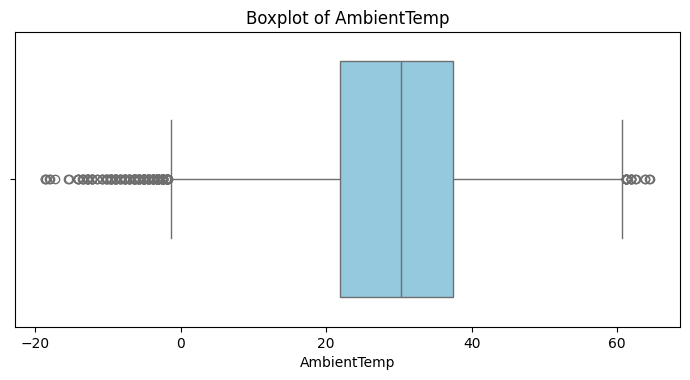

In [80]:
# Boxplot before handling outliers
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7))
axes = axes.flatten()

for i in range(len(columns_to_handle_outliers)) :
  sns.boxplot(data = df_train_handling_outliers, ax=axes[i], x=columns_to_handle_outliers[i], orient='h', color='skyblue')
  axes[i].set_title(f'Boxplot of {columns_to_handle_outliers[i]}')


# Remove the last subplot if there are fewer features than subplots
if len(columns_to_handle_outliers) < len(axes):
    axes[len(columns_to_handle_outliers)].remove()

plt.tight_layout()

In [81]:
# Remove outliers with IQR method

print(f'The number of rows before filtering out outliers : {len(df_train_handling_outliers)}')

filtered_entries = np.array([True] * len(df_train_handling_outliers))

# Select features with outliers
for col in columns_to_handle_outliers:

    Q1 = df_train_handling_outliers[col].quantile(0.25)
    Q3 = df_train_handling_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (IQR * 1.5)
    upper_bound = Q3 + (IQR * 1.5)

    filtered_entries = ((df_train_handling_outliers[col] >= lower_bound) & (df_train_handling_outliers[col] <= upper_bound)) & filtered_entries

df_train_handling_outliers = df_train_handling_outliers[filtered_entries]

print(f'The number of rows after filtering out outliers: {len(df_train_handling_outliers)}')

The number of rows before filtering out outliers : 15783
The number of rows after filtering out outliers: 15601


In [82]:
# # Remove outliers with z-score method

# from scipy import stats

# print(f'The number of rows before filtering out outliers : {len(df_train_handling_outliers)}')

# filtered_entries = np.array([True] * len(df_train_handling_outliers))

# # Select features with outliers
# for col in columns_to_handle_outliers:
#     zscore = abs(stats.zscore(df_train_handling_outliers[col])) # calculate the absolute z-score
#     filtered_entries = (zscore < 3) & filtered_entries # keep z-score values less than absolute 3
    
# df_train_handling_outliers = df_train_handling_outliers[filtered_entries]

# print(f'The number of rows after filtering out outliers: {len(df_train_handling_outliers)}')

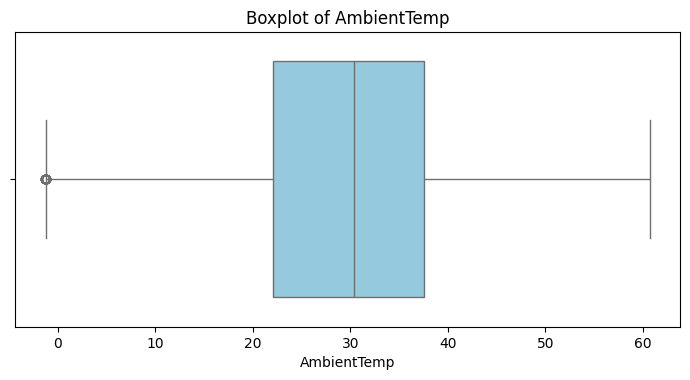

In [83]:
# Boxplot after handling outliers
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7))
axes = axes.flatten()

for i in range(len(columns_to_handle_outliers)) :
  sns.boxplot(data = df_train_handling_outliers, ax=axes[i], x=columns_to_handle_outliers[i], orient='h', color='skyblue')
  axes[i].set_title(f'Boxplot of {columns_to_handle_outliers[i]}')


# Remove the last subplot if there are fewer features than subplots
if len(columns_to_handle_outliers) < len(axes):
    axes[len(columns_to_handle_outliers)].remove()

plt.tight_layout()

In [84]:
# Split the features and target for train set again
X_train = df_train_handling_outliers.drop(columns='PolyPwr')
y_train = df_train_handling_outliers['PolyPwr']

# Feature Scaling

Scaling will be done to train and test data

In [85]:
display(X_train)
display(X_test)

,AmbientTemp,Pressure,Cloud.Ceiling,Humidity,Hour,Month,Season_Spring,Season_Summer,Season_Winter
425,34.77821,1008.2,40,18.21289,14,5,1,0,0
16997,15.55305,1018.4,722,73.35815,15,1,0,0,1
17963,28.46886,1011.3,722,39.66064,13,6,0,1,0
6491,34.91920,1021.6,34,39.83154,12,3,1,0,0
4693,30.30678,857.2,722,17.33398,10,7,0,1,0
...,...,...,...,...,...,...,...,...,...
11284,35.43030,960.1,722,25.92163,14,8,0,1,0
11964,28.32787,984.9,60,60.22949,15,8,0,1,0
5390,42.57805,1019.3,722,42.46216,12,8,0,1,0
860,24.49341,1010.9,18,60.41870,10,8,0,1,0


,AmbientTemp,Pressure,Cloud.Ceiling,Humidity,Hour,Month,Season_Spring,Season_Summer,Season_Winter
20644,34.77318,805.6,24,35.69336,11,7,0,1,0
20802,58.63594,804.5,120,10.96802,15,8,0,1,0
6836,25.25124,1014.8,70,71.70410,13,11,0,0,0
5865,41.87813,1012.8,722,36.25488,13,11,0,0,0
7628,31.05705,1014.8,722,53.44849,14,5,1,0,0
...,...,...,...,...,...,...,...,...,...
9273,41.25374,960.1,722,19.97681,11,7,0,1,0
5359,43.83942,1013.5,722,38.82446,14,7,0,1,0
12872,24.45816,975.1,50,96.44775,11,8,0,1,0
3288,21.99333,849.9,722,27.18506,14,10,0,0,0


**Additional Reminder About Feature Scalling**

When the original distribution is right-skewed, meaning that the majority of the data is concentrated on the left side with a long tail to the right, it's often more appropriate to use transformations that are less sensitive to extreme values. In this case, Min-Max scaling may be a better choice than Z-score normalization.

Here's a brief explanation:

1. **Min-Max Scaling:**
   - Scales the data to a specific range (e.g., between 0 and 1).
   - Less affected by outliers compared to Z-score normalization.
   - Suitable when the distribution is not normal and skewed.

2. **Z-score Normalization (Standardization):**
   - Centers the data around the mean and scales it by the standard deviation.
   - Can be sensitive to outliers, and right-skewed distributions may have extreme values that influence the scaling.
   - More appropriate when the data is approximately normally distributed.

Given a right-skewed distribution, Min-Max scaling is often a better choice as it allows the preservation of the skewed shape of the distribution and avoids amplifying the impact of outliers. However, the choice may also depend on the specific characteristics of your data and the requirements of your modeling task. If your data has extreme outliers, you might also consider other robust scaling methods.

In [86]:
len(X_train.columns)

9

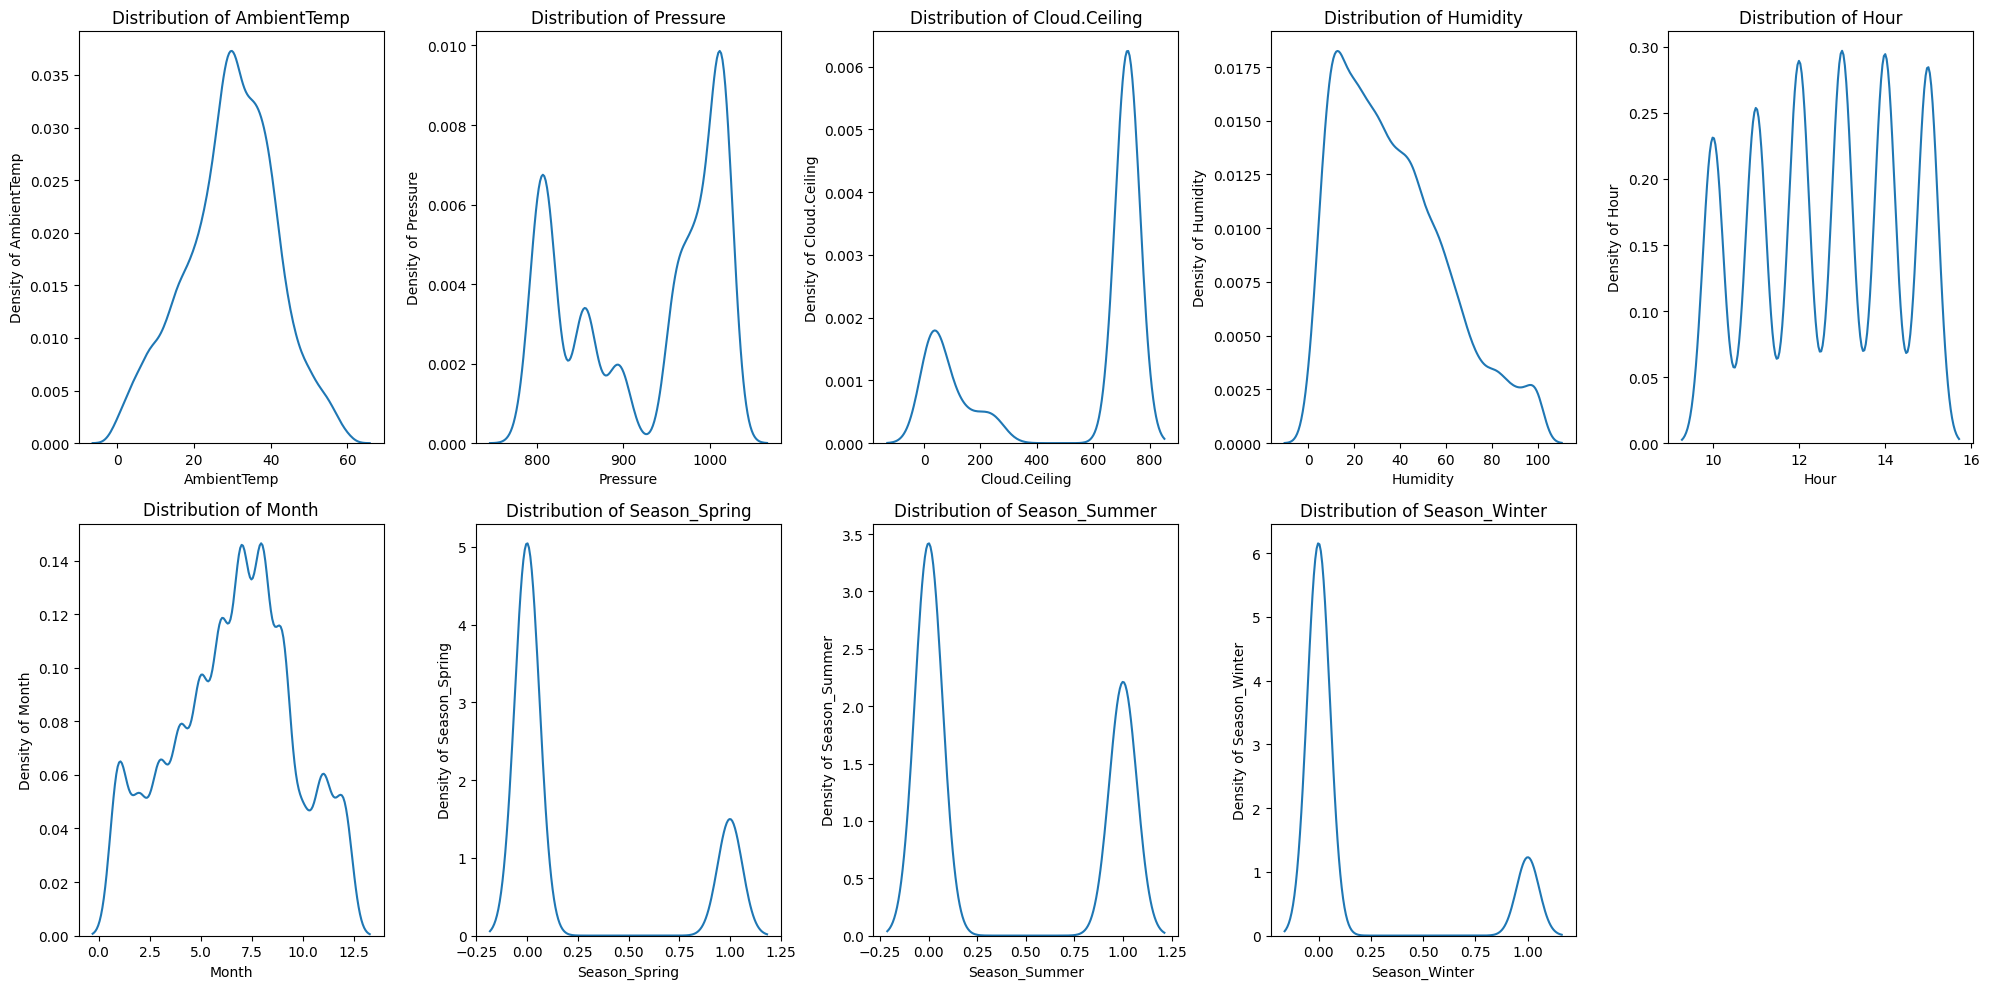

In [88]:
# Checking distribution before scaling
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))
axes = axes.flatten()

for i in range(len(X_train.columns)) :
    sns.kdeplot(data=X_train, ax=axes[i], x=X_train.columns[i])
    axes[i].set_title(f'Distribution of {X_train.columns[i]}')
    axes[i].set_ylabel(f'Density of {X_train.columns[i]}')
    axes[i].set_xlabel(f'{X_train.columns[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(X_train.columns) < len(axes) :
    axes[len(X_train.columns)].remove()

plt.tight_layout()
plt.show()

**Additional thing to remember about scaling multi-modal distribution**

- When dealing with features that have a multi-modal distribution, like the hour feature you mentioned with values [10, 11, 12, 13, 14, 15], scaling might not be as crucial as it is for some other types of data. Scaling is typically more important when working with algorithms that are sensitive to the scale of the input features, such as distance-based algorithms (e.g., k-nearest neighbors) or optimization algorithms (e.g., gradient descent).

- For categorical features like hours of the day, you might consider using techniques like one-hot encoding or ordinal encoding, depending on the nature of the data and the specific machine learning algorithm you plan to use. One-hot encoding represents each category as a binary column, while ordinal encoding assigns integer values based on the order of the categories.

- If you still want to scale the feature for some reason, you can use techniques like Min-Max scaling or Z-score normalization. However, keep in mind that the choice of scaling method might depend on the characteristics of your data and the requirements of your specific machine learning model. Since the hour feature has a limited range, scaling might not have a significant impact on its distribution. Always consider the context and the characteristics of your data when deciding whether or not to scale a particular feature.

We will do scaling for non-binary features that we got in encoding process, so we will do this on Humidity, AmbientTemp, Wind.Speed, Visibility, Pressure, and Cloud.Ceiling

In [89]:
# Feature scaling - MinMaxScaler is better for skewed distributions
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

columns_to_scale = ['Humidity', 'AmbientTemp', 'Pressure', 'Cloud.Ceiling', 'Month', 'Hour']

# Apply scaling to training data and fit the scaler
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# Apply the same transformation to test data
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

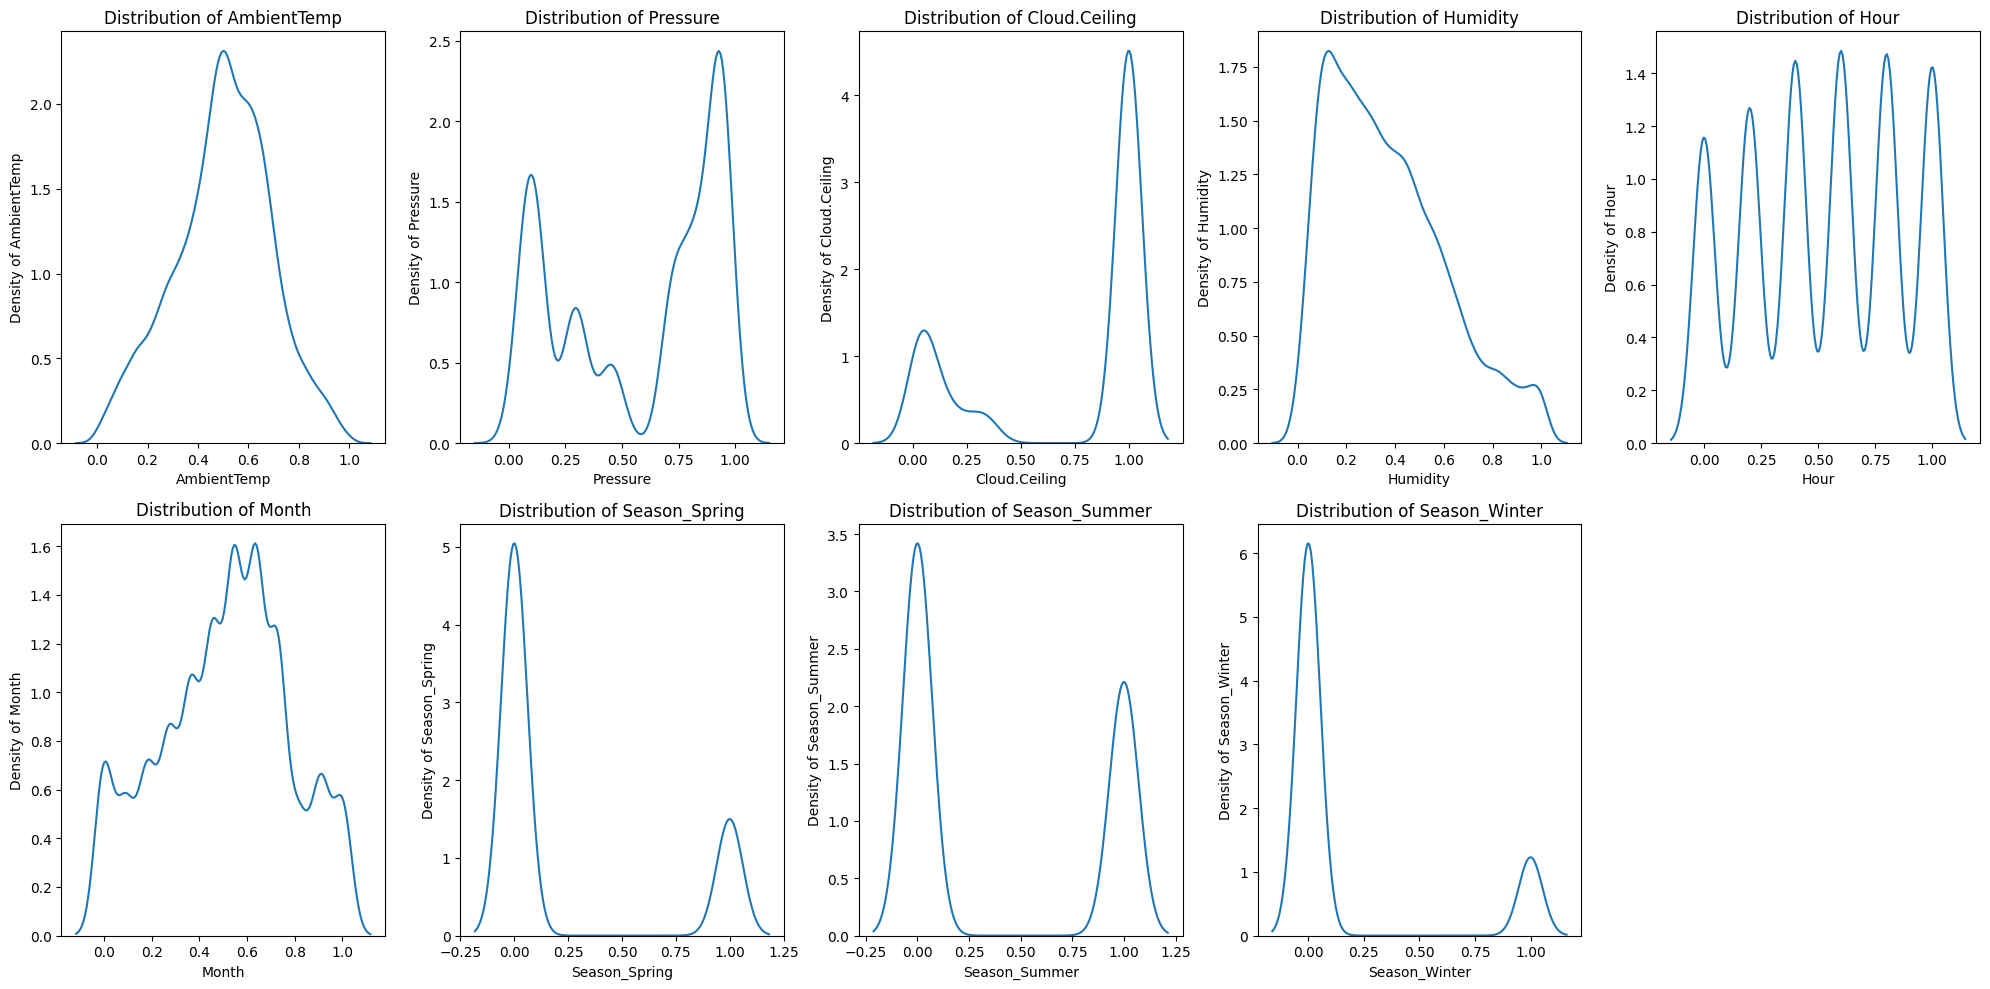

In [91]:
# Checking distribution after scaling
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))
axes = axes.flatten()

for i in range(len(X_train.columns)) :
    sns.kdeplot(data=X_train, ax=axes[i], x=X_train.columns[i])
    axes[i].set_title(f'Distribution of {X_train.columns[i]}')
    axes[i].set_ylabel(f'Density of {X_train.columns[i]}')
    axes[i].set_xlabel(f'{X_train.columns[i]}')

# Remove the last subplot if there are fewer features than subplots
if len(X_train.columns) < len(axes) :
    axes[len(X_train.columns)].remove()

plt.tight_layout()

# Modelling

## Helper Functions

In [97]:
# Import metrics score that will be evalueated
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_validate, RepeatedKFold

#Function for model evaluation metrics score
def eval_regression(
    model,
    X_test,
    y_test,
    X_train,
    y_train,
    custom_metrics=None,
    n_splits=5,
    n_repeats=3,
    random_state=42
) -> dict:
    """
    Comprehensively evaluate a regression model using multiple metrics 
    and cross-validation techniques.

    Parameters:
    -----------
    model : sklearn estimator
        The regression model to be evaluated
    X_test : array-like
        Test feature dataset
    y_test : array-like
        Test target values
    X_train : array-like
        Training feature dataset
    y_train : array-like
        Training target values
    custom_metrics : dict, optional (default=None)
        Additional custom metric functions to evaluate
        Format: {'metric_name': metric_function}
    n_splits : int, optional (default=5)
        Number of splits for cross-validation
    n_repeats : int, optional (default=3)
        Number of times to repeat cross-validation
    random_state : int, optional (default=42)
        Seed for reproducibility of cross-validation splits

    Returns:
    --------
    dict
        Comprehensive dictionary of model performance metrics
    """
    try:
        # Utility function to convert input to numpy array
        def to_numpy(arr):
            """Convert pandas DataFrame/Series to numpy array if necessary."""
            if isinstance(arr, (pd.DataFrame, pd.Series)):
                return arr.to_numpy()
            return arr

        # Convert all input data to numpy arrays
        X_test = to_numpy(X_test)
        y_test = to_numpy(y_test)
        X_train = to_numpy(X_train)
        y_train = to_numpy(y_train)

        # Initialize metrics dictionary to store all evaluation results
        metrics = {}

        # Perform single-run predictions on test and train datasets
        y_pred_test = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        # Setup cross-validation strategy
        cv = RepeatedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=random_state
        )

        # Define standard metrics to evaluate
        scoring = {
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        }

        # Add MAPE as a custom scorer (not built-in to sklearn)
        def mape_scorer(estimator, X, y):
            y_pred = estimator.predict(X)
            return -mean_absolute_percentage_error(y, y_pred)  # Negative for sklearn's scoring convention
        
        # Perform cross-validation with multiple metrics
        cv_scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring={**scoring, 'mape': mape_scorer},
            return_train_score=True,
            n_jobs=-1  # Use all available CPU cores
        )

        # Store cross-validated metrics
        metrics['cv'] = {}

        # Process each metric from cross-validation
        for metric in list(scoring.keys()) + ['mape']:
            test_scores = cv_scores[f'test_{metric}']
            train_scores = cv_scores[f'train_{metric}']
            
            # For negative metrics, convert back to positive
            if metric in ['mae', 'rmse', 'mape']:
                test_scores = -test_scores
                train_scores = -train_scores

            # Store mean and standard deviation of cross-validated scores
            metrics['cv'][metric] = {
                'test_mean': test_scores.mean(),
                'test_std': test_scores.std(),
                'train_mean': train_scores.mean(),
                'train_std': train_scores.std()
            }

        # Store single-run metrics
        metrics['mae'] = {
            'test': mean_absolute_error(y_test, y_pred_test),
            'train': mean_absolute_error(y_train, y_pred_train)
        }
        
        metrics['rmse'] = {
            'test': mean_squared_error(y_test, y_pred_test, squared=False),
            'train': mean_squared_error(y_train, y_pred_train, squared=False)
        }
        
        metrics['mape'] = {
            'test': mean_absolute_percentage_error(y_test, y_pred_test),
            'train': mean_absolute_percentage_error(y_train, y_pred_train)
        }
        
        metrics['r2'] = {
            'test': r2_score(y_test, y_pred_test),
            'train': r2_score(y_train, y_pred_train)
        }

        # Add custom metrics if provided
        if custom_metrics:
            for metric_name, metric_func in custom_metrics.items():
                metrics[metric_name] = {
                    'test': metric_func(y_test, y_pred_test),
                    'train': metric_func(y_train, y_pred_train)
                }

        # Print results
        print(f"Performance Metrics for {model.__class__.__name__}:")
        print("\nCross-Validated Metrics (mean ± std):")
        for metric in metrics['cv'].keys():
            print(f"\n{metric.upper()}:")
            if metric == 'r2':
                print(f"  Test:  {metrics['cv'][metric]['test_mean']:.4f} ± {metrics['cv'][metric]['test_std']:.4f}")
                print(f"  Train: {metrics['cv'][metric]['train_mean']:.4f} ± {metrics['cv'][metric]['train_std']:.4f}")
            else:
                print(f"  Test:  {metrics['cv'][metric]['test_mean']:.4f} ± {metrics['cv'][metric]['test_std']:.4f}")
                print(f"  Train: {metrics['cv'][metric]['train_mean']:.4f} ± {metrics['cv'][metric]['train_std']:.4f}")

        print("\nSingle Run Metrics:")
        for metric in metrics.keys():
            if metric != 'cv':
                print(f"\n{metric.upper()}:")
                print(f"  Test:  {metrics[metric]['test']:.4f}")
                print(f"  Train: {metrics[metric]['train']:.4f}")

        return metrics

    except Exception as e:
        print(f"Error during evaluation: {str(e)}")
        raise

In [130]:
import time
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.metrics import get_scorer, r2_score, mean_squared_error, mean_absolute_error
from tqdm.notebook import tqdm

# Function for hyperparameter tuning
def grid_pipe(
    pipedict: dict,
    param_grid: dict,
    X_train,
    y_train,
    X_test,
    y_test,
    scoring='r2',
    n_splits=5,
    n_repeats=3,
    display=True,
    n_jobs=-1,
    plot_learning_curves=True,
    progress_bar=False
) -> tuple:
    """
    Perform grid search cross-validation with optional learning curve plots for multiple regression pipelines.

    Parameters:
    -----------
    pipedict : dict
        Dictionary of pipeline names and their corresponding pipeline objects
    param_grid : dict
        Dictionary of parameter grids for each pipeline
    X_train, y_train : array-like
        Training data
    X_test, y_test : array-like
        Test data
    scoring : str, optional (default='r2')
        Metric to optimize during grid search (e.g., 'r2', 'neg_mean_squared_error', 'neg_mean_absolute_error')
    n_splits : int, optional (default=5)
        Number of splits for cross-validation
    n_repeats : int, optional (default=3)
        Number of times to repeat cross-validation
    display : bool, optional (default=True)
        Whether to display detailed results
    n_jobs : int, optional (default=-1)
        Number of CPU cores to use
    plot_learning_curves : bool, optional (default=True)
        Whether to plot learning curves for each parameter
    progress_bar : bool, optional (default=False)
        Whether to display a progress bar for parameter evaluations

    Returns:
    --------
    tuple
        (dictionary of fitted GridSearchCV objects, list of fitting times)
    """


    fitted_models = {}
    fit_times = []

    # Wrap pipeline iteration with optional tqdm
    pipe_iter = tqdm(pipedict.items(), desc="Processing Pipelines",
                    position=0, leave=True) if progress_bar else pipedict.items()

    for name, pipeline in pipe_iter:
        try:
            if plot_learning_curves:
                # Get the parameter grid for the current pipeline
                current_params = param_grid[name]
                
                # Wrap param_grid iteration with optional tqdm
                param_iter = tqdm(current_params.items(), desc=f"Evaluating Parameters for {name}",
                                position=1, leave=True) if progress_bar else current_params.items()

                for param_name, param_values in param_iter:
                    if not isinstance(param_values, (list, np.ndarray)):
                        continue

                    # Skip parameters that aren't numeric or have too few values
                    if len(param_values) < 2:
                        continue

                    # Initialize score lists
                    train_scores = []
                    test_scores = []
                    difference_scores = []

                    if display:
                        print(f"\nEvaluating {param_name} for {name}...")

                    for value in param_values:
                        # Create a copy of the pipeline with the current parameter value
                        current_pipeline = clone(pipeline)
                        current_pipeline.set_params(**{param_name: value})

                        # Fit and evaluate
                        current_pipeline.fit(X_train, y_train)

                        # Get predictions
                        y_pred_train = current_pipeline.predict(X_train)
                        y_pred_test = current_pipeline.predict(X_test)
                        
                        # Handle different scoring metrics for regression
                        if scoring == 'r2':
                            score_func = r2_score
                            # For R2, higher is better
                            train_score = score_func(y_train, y_pred_train)
                            test_score = score_func(y_test, y_pred_test)
                        elif scoring == 'neg_mean_squared_error':
                            # For MSE, lower is better, but sklearn uses negative for maximization
                            train_score = -mean_squared_error(y_train, y_pred_train)
                            test_score = -mean_squared_error(y_test, y_pred_test)
                        elif scoring == 'neg_root_mean_squared_error':
                            # For RMSE, lower is better, but sklearn uses negative for maximization
                            train_score = -mean_squared_error(y_train, y_pred_train, squared=False)
                            test_score = -mean_squared_error(y_test, y_pred_test, squared=False)
                        elif scoring == 'neg_mean_absolute_error':
                            # For MAE, lower is better, but sklearn uses negative for maximization
                            train_score = -mean_absolute_error(y_train, y_pred_train)
                            test_score = -mean_absolute_error(y_test, y_pred_test)
                        else:
                            # Use sklearn's scorer for other metrics
                            score_func = get_scorer(scoring)._score_func
                            train_score = score_func(y_train, y_pred_train)
                            test_score = score_func(y_test, y_pred_test)

                        diff_score = train_score - test_score

                        train_scores.append(train_score)
                        test_scores.append(test_score)
                        difference_scores.append(diff_score)

                        if display:
                            print(f'{param_name}: {value}; '
                                 f'train: {train_score:.3f}; '
                                 f'test: {test_score:.3f}; '
                                 f'diff: {diff_score:.3f}')

                    # Plot learning curve
                    plt.figure(figsize=(10, 6))
                    plt.plot(param_values, train_scores, 'o-', label='Train')
                    plt.plot(param_values, test_scores, 'o-', label='Test')

                    # Find best parameter value based on test score
                    if 'neg_' in scoring:
                        # For negative metrics, higher values are better
                        best_idx = np.argmax(test_scores)
                    else:
                        # For positive metrics like R2, higher values are better
                        best_idx = np.argmax(test_scores)
                        
                    best_value = param_values[best_idx]
                    best_score = test_scores[best_idx]

                    # Add vertical line and annotation for best value
                    plt.axvline(x=best_value, color='r', linestyle='--', alpha=0.5)
                    
                    # Format the score display based on the metric
                    if 'neg_' in scoring:
                        display_score = -best_score  # Convert back to positive for display
                        metric_name = scoring.replace('neg_', '')
                    else:
                        display_score = best_score
                        metric_name = scoring
                        
                    plt.annotate(f'Best {param_name}: {best_value}\n'
                                f'Best {metric_name}: {display_score:.3f}',
                                xy=(best_value, best_score),
                                xytext=(10, 10), textcoords='offset points',
                                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

                    plt.title(f'Learning Curve: {scoring.upper()} | {param_name} | {name}')
                    plt.xlabel(param_name)
                    plt.ylabel(scoring.upper())
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    plt.show()

            # Construct grid search with RepeatedKFold for regression
            cv = RepeatedKFold(
                n_splits=n_splits,
                n_repeats=n_repeats,
                random_state=42
            )

            model = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid[name],
                scoring=scoring,
                cv=cv,
                verbose=2 if display else 0,
                n_jobs=n_jobs,
                return_train_score=True,
                error_score='raise'
            )

            # Fit using grid search with timing
            start_time = time.time()
            model.fit(X_train, y_train)
            fit_time = time.time() - start_time
            fit_times.append(round(fit_time, 2))

            # Store fitted model
            fitted_models[name] = model

            if display:
                print(f"\nGrid Search Results for {name}:")
                print("-" * 50)
                print(f"Total Fit Time: {fit_time:.3f}s")
                
                # Format the score display based on the metric
                if 'neg_' in scoring:
                    display_score = -model.best_score_  # Convert back to positive for display
                    metric_name = scoring.replace('neg_', '')
                    print(f"Best {metric_name}: {display_score:.3f}")
                else:
                    print(f"Best {scoring}: {model.best_score_:.3f}")
                    
                print("\nBest Parameters:")
                for param, value in model.best_params_.items():
                    print(f"{param}: {value}")
                print()

        except Exception as e:
            print(f"Error during {name} pipeline tuning: {str(e)}")
            continue

    return fitted_models, fit_times

In [ ]:
# # Previous Version Implementation
# #Import metrics score that will be evalueated
# from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
# from sklearn.model_selection import cross_validate

# #Function for model evaluation metrics score
# def eval_regression(model):
#   y_pred = model.predict(X_test)
#   y_pred_train = model.predict(X_train)

#   # print(f'MAE (train): {mean_absolute_error(y_test, y_pred_train)}')
#   print(f'MAE (test): {mean_absolute_error(y_test, y_pred)}')

#   # print(f'RMSE (train): {mean_squared_error(y_train, y_pred_train, squared=False)}')
#   print(f'RMSE (test): {mean_squared_error(y_test, y_pred, squared=False)}')

#   # print(f'MAPE (train): {mean_absolute_percentage_error(y_train, y_pred_train)}')
#   print(f'MAPE (test): {mean_absolute_percentage_error(y_test, y_pred)}')

#   # print(f'R2 (train): {r2_score(y_train, y_pred_train)}')
#   print(f'R2 (test): {r2_score(y_test, y_pred)}')

#   #Cross Validation
#   score = cross_validate(model, X_train, y_train, cv=5, scoring='r2', return_train_score=True) #scoring change based on what metrics we want to validate (usually choose the main performance metric)
#   print(f'R2 Score (crossval train): {score["train_score"].mean()}')
#   print(f'R2 Score (crossval test): {score["test_score"].mean()}')

## Train Vanilla Models

In [92]:
# Check the amount of training and test data
print(f'Dimension of x_train data : {X_train.shape}')
print(f'Dimension of x_test data : {X_test.shape}')

Dimension of x_train data : (15601, 9)
Dimension of x_test data : (5262, 9)


In [96]:
# Import models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# Initialize object for each model
lr = LinearRegression()
ridge = Ridge()
lasso = Lasso()
elasticnet = ElasticNet()
knn = KNeighborsRegressor()
svr = SVR()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)
ab = AdaBoostRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)
nn = MLPRegressor(random_state=42)

models = [lr, ridge, lasso, elasticnet, knn, svr, dt, rf, gb, ab, xgb, nn]

# Train models
for model in models:
    model.fit(X_train, y_train)

## Evaluate Vanilla Models

In [103]:
# # # Previous Version Implementation
# # Printing metrics score for all models to compare

# #Linear Regression
# print('\nEvaluate LinearRegression')
# eval_regression(lr)

# #Ridge Regressor
# print('\nEvaluate RidgeRegression')
# eval_regression(ridge)

# #Lasso Regressor
# print('\nEvaluate LassoRegression')
# eval_regression(lasso)

# #Elastic Net Regressor
# print('\nEvaluate ElasticNetRegression')
# eval_regression(elasticnet)

# #K-Nearest Neighbors Regressor
# print('\nEvaluate KNeighborsRegressor')
# eval_regression(knn)

# #Support Vector Regressor
# print('\nEvaluate SVR')
# eval_regression(svr)

# #Decision Tree Regressor
# print('\nEvaluate DecisionTreeRegressor')
# eval_regression(dt)

# #Random Forest Regressor
# print('\nEvaluate RandomForestRegressor')
# eval_regression(rf)

# #Gradient Boosting Regressor
# print('\nEvaluate GradientBoostingRegressor')
# eval_regression(gb)

# #AdaBoost Regressor
# print('\nEvaluate AdaBoostRegressor')
# eval_regression(ab)

# #XGBoost Regressor
# print('\nEvaluate XGBRegressor')
# eval_regression(xgb)

# #MLP Regression
# print('\nEvaluate MLPRegressor')
# eval_regression(nn)

### Linear Regression

In [98]:
results_lr = eval_regression(lr, X_test, y_test, X_train, y_train)

Performance Metrics for LinearRegression:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  4.0650 ± 0.0490
  Train: 4.0608 ± 0.0130

RMSE:
  Test:  5.1918 ± 0.0717
  Train: 5.1873 ± 0.0179

R2:
  Test:  0.4641 ± 0.0115
  Train: 0.4653 ± 0.0029

MAPE:
  Test:  0.7366 ± 0.0401
  Train: 0.7359 ± 0.0090

Single Run Metrics:

MAE:
  Test:  3.9970
  Train: 4.0613

RMSE:
  Test:  5.1289
  Train: 5.1878

MAPE:
  Test:  0.7358
  Train: 0.7360

R2:
  Test:  0.4837
  Train: 0.4653


### Ridge Regression

In [100]:
results_ridge = eval_regression(ridge, X_test, y_test, X_train, y_train)

Performance Metrics for Ridge:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  4.0649 ± 0.0491
  Train: 4.0607 ± 0.0130

RMSE:
  Test:  5.1918 ± 0.0717
  Train: 5.1873 ± 0.0179

R2:
  Test:  0.4641 ± 0.0115
  Train: 0.4653 ± 0.0029

MAPE:
  Test:  0.7368 ± 0.0401
  Train: 0.7361 ± 0.0090

Single Run Metrics:

MAE:
  Test:  3.9968
  Train: 4.0612

RMSE:
  Test:  5.1289
  Train: 5.1878

MAPE:
  Test:  0.7359
  Train: 0.7362

R2:
  Test:  0.4837
  Train: 0.4653


### Lasso Regression

In [101]:
results_lasso = eval_regression(lasso, X_test, y_test, X_train, y_train)

Performance Metrics for Lasso:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  5.9364 ± 0.0655
  Train: 5.9355 ± 0.0180

RMSE:
  Test:  6.8929 ± 0.0615
  Train: 6.8919 ± 0.0194

R2:
  Test:  0.0556 ± 0.0012
  Train: 0.0562 ± 0.0031

MAPE:
  Test:  1.2370 ± 0.0528
  Train: 1.2368 ± 0.0106

Single Run Metrics:

MAE:
  Test:  5.9662
  Train: 5.9356

RMSE:
  Test:  6.9302
  Train: 6.8920

MAPE:
  Test:  1.2773
  Train: 1.2368

R2:
  Test:  0.0574
  Train: 0.0562


### ElasticNet Regression

In [102]:
results_elasticnet = eval_regression(elasticnet, X_test, y_test, X_train, y_train)

Performance Metrics for ElasticNet:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  5.8266 ± 0.0656
  Train: 5.8257 ± 0.0155

RMSE:
  Test:  6.7832 ± 0.0622
  Train: 6.7823 ± 0.0160

R2:
  Test:  0.0854 ± 0.0020
  Train: 0.0860 ± 0.0018

MAPE:
  Test:  1.2157 ± 0.0514
  Train: 1.2155 ± 0.0108

Single Run Metrics:

MAE:
  Test:  5.8566
  Train: 5.8258

RMSE:
  Test:  6.8197
  Train: 6.7825

MAPE:
  Test:  1.2582
  Train: 1.2155

R2:
  Test:  0.0872
  Train: 0.0860


### K-Nearest Neighbours

In [105]:
results_knn = eval_regression(knn, X_test, y_test, X_train, y_train)

Performance Metrics for KNeighborsRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  3.1556 ± 0.0507
  Train: 2.5494 ± 0.0169

RMSE:
  Test:  4.6236 ± 0.0860
  Train: 3.7700 ± 0.0236

R2:
  Test:  0.5750 ± 0.0137
  Train: 0.7176 ± 0.0032

MAPE:
  Test:  0.5555 ± 0.0324
  Train: 0.4445 ± 0.0073

Single Run Metrics:

MAE:
  Test:  3.1337
  Train: 2.5216

RMSE:
  Test:  4.6452
  Train: 3.7487

MAPE:
  Test:  0.5494
  Train: 0.4399

R2:
  Test:  0.5765
  Train: 0.7208


### Support Vector Machine

In [114]:
# results_svm = eval_regression(svr, X_test, y_test, X_train, y_train)

### Decision Tree

In [108]:
results_dt = eval_regression(dt, X_test, y_test, X_train, y_train)

Performance Metrics for DecisionTreeRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  3.8810 ± 0.0820
  Train: 0.0000 ± 0.0000

RMSE:
  Test:  5.9658 ± 0.0987
  Train: 0.0000 ± 0.0000

R2:
  Test:  0.2924 ± 0.0194
  Train: 1.0000 ± 0.0000

MAPE:
  Test:  0.6098 ± 0.0367
  Train: 0.0000 ± 0.0000

Single Run Metrics:

MAE:
  Test:  3.7439
  Train: 0.0000

RMSE:
  Test:  5.8096
  Train: 0.0000

MAPE:
  Test:  0.5988
  Train: 0.0000

R2:
  Test:  0.3376
  Train: 1.0000


### Random Forest

In [109]:
results_rf = eval_regression(rf, X_test, y_test, X_train, y_train)

Performance Metrics for RandomForestRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  2.9399 ± 0.0584
  Train: 1.0920 ± 0.0083

RMSE:
  Test:  4.2957 ± 0.0875
  Train: 1.6103 ± 0.0110

R2:
  Test:  0.6331 ± 0.0124
  Train: 0.9485 ± 0.0007

MAPE:
  Test:  0.5180 ± 0.0348
  Train: 0.1912 ± 0.0032

Single Run Metrics:

MAE:
  Test:  2.8810
  Train: 1.0766

RMSE:
  Test:  4.2433
  Train: 1.5955

MAPE:
  Test:  0.5113
  Train: 0.1893

R2:
  Test:  0.6466
  Train: 0.9494


### Gradient Boosting

In [110]:
results_db = eval_regression(gb, X_test, y_test, X_train, y_train)

Performance Metrics for GradientBoostingRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  3.2647 ± 0.0409
  Train: 3.1772 ± 0.0126

RMSE:
  Test:  4.4500 ± 0.0744
  Train: 4.3351 ± 0.0170

R2:
  Test:  0.6063 ± 0.0106
  Train: 0.6266 ± 0.0023

MAPE:
  Test:  0.5757 ± 0.0334
  Train: 0.5587 ± 0.0075

Single Run Metrics:

MAE:
  Test:  3.2140
  Train: 3.1952

RMSE:
  Test:  4.3994
  Train: 4.3540

MAPE:
  Test:  0.5653
  Train: 0.5612

R2:
  Test:  0.6201
  Train: 0.6233


### Adaboost

In [111]:
results_ab = eval_regression(ab, X_test, y_test, X_train, y_train)

Performance Metrics for AdaBoostRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  4.5166 ± 0.0777
  Train: 4.4978 ± 0.0582

RMSE:
  Test:  5.3774 ± 0.0671
  Train: 5.3442 ± 0.0531

R2:
  Test:  0.4251 ± 0.0122
  Train: 0.4325 ± 0.0105

MAPE:
  Test:  0.8738 ± 0.0460
  Train: 0.8680 ± 0.0231

Single Run Metrics:

MAE:
  Test:  4.4870
  Train: 4.4962

RMSE:
  Test:  5.3556
  Train: 5.3368

MAPE:
  Test:  0.8968
  Train: 0.8621

R2:
  Test:  0.4371
  Train: 0.4341


### Xtreme Gradient Boost

In [112]:
results_xgb = eval_regression(xgb, X_test, y_test, X_train, y_train)

Performance Metrics for XGBRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  3.0283 ± 0.0556
  Train: 1.9965 ± 0.0223

RMSE:
  Test:  4.3444 ± 0.0922
  Train: 2.8574 ± 0.0308

R2:
  Test:  0.6247 ± 0.0131
  Train: 0.8378 ± 0.0034

MAPE:
  Test:  0.5280 ± 0.0357
  Train: 0.3377 ± 0.0071

Single Run Metrics:

MAE:
  Test:  2.9762
  Train: 2.1274

RMSE:
  Test:  4.2893
  Train: 3.0478

MAPE:
  Test:  0.5156
  Train: 0.3629

R2:
  Test:  0.6389
  Train: 0.8154


### MLP

In [113]:
results_mlp = eval_regression(nn, X_test, y_test, X_train, y_train)

Performance Metrics for MLPRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  3.4689 ± 0.0559
  Train: 3.4376 ± 0.0181

RMSE:
  Test:  4.6630 ± 0.0880
  Train: 4.6237 ± 0.0232

R2:
  Test:  0.5677 ± 0.0135
  Train: 0.5752 ± 0.0038

MAPE:
  Test:  0.6088 ± 0.0381
  Train: 0.6032 ± 0.0113

Single Run Metrics:

MAE:
  Test:  3.4717
  Train: 3.4640

RMSE:
  Test:  4.6491
  Train: 4.6399

MAPE:
  Test:  0.6084
  Train: 0.6096

R2:
  Test:  0.5758
  Train: 0.5722


## (Additional) Feature Importance in Linear Models

In [117]:
# Check features
X_train.columns

Index(['AmbientTemp', 'Pressure', 'Cloud.Ceiling', 'Humidity', 'Hour', 'Month',
       'Season_Spring', 'Season_Summer', 'Season_Winter'],
      dtype='object')

In [116]:
# Flatten the coefficient arrays
lr_coef = pd.Series(lr.coef_.flatten())
ridge_coef = pd.Series(ridge.coef_.flatten())
lasso_coef = pd.Series(lasso.coef_.flatten())
elasticnet_coef = pd.Series(elasticnet.coef_.flatten())

# Creating a DataFrame with coefficients
linear_model_coef = pd.DataFrame({'lr_coef': lr_coef,
                                  'ridge_coef': ridge_coef,
                                  'lasso_coef': lasso_coef,
                                  'elasticnet_coef': elasticnet_coef})

# Add feature names to the DataFrame
linear_model_coef['Feature'] = X_train.columns

# Set 'Feature' as the index
linear_model_coef.set_index('Feature', inplace=True)

# Display coef DataFrame
display(linear_model_coef)

,lr_coef,ridge_coef,lasso_coef,elasticnet_coef
Feature,,,,
AmbientTemp,15.360806,15.309208,0.000000,0.402027
Pressure,3.832650,3.833139,0.000000,0.000000
Cloud.Ceiling,3.803833,3.805541,1.274399,1.029954
Humidity,-4.107360,-4.121223,-0.000000,-0.151740
Hour,0.082506,0.086105,0.000000,0.000000
Month,-2.550025,-2.548345,-0.000000,-0.000000
Season_Spring,3.037409,3.033799,0.000000,0.000000
Season_Summer,1.703875,1.708023,0.000000,0.448632
Season_Winter,-1.349923,-1.357633,-0.000000,-0.357975


## Summary of Models Generated by Various Machine Learning Algorithms

Experiment was conducted on the models below:

1. Linear Regression (with regularization: Ridge, Lasso, and Elastic Net)
2. K-Nearest Neighbors (KNN) Regression
3. Support Vector Regression (SVR)
4. Decision Tree Regression
5. Random Forest Regression
6. Gradient Boosting Regression
7. AdaBoost Regression
8. XGBoost Regression
9. Multi-Layer Perceptron (MLP) Regression

From all of the models, the best results were obtained by:

- **Random Forest Regression**
- **XGBoost Regression**

Therefore, hyperparameter tuning can be applied to these two models to slightly improve their results (for other models that also have decent performance, experiments will be conducted if there is time and additional resources available).

## Feature Importances from Regression Models

In [120]:
# Function for model feature importance score
def show_feature_importance(model):
    feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
    ax = feat_importances.nlargest(25).plot(kind='barh', figsize=(10, 8))
    ax.invert_yaxis()

    plt.xlabel('Score')
    plt.ylabel('Feature')
    plt.title('Feature importance score')

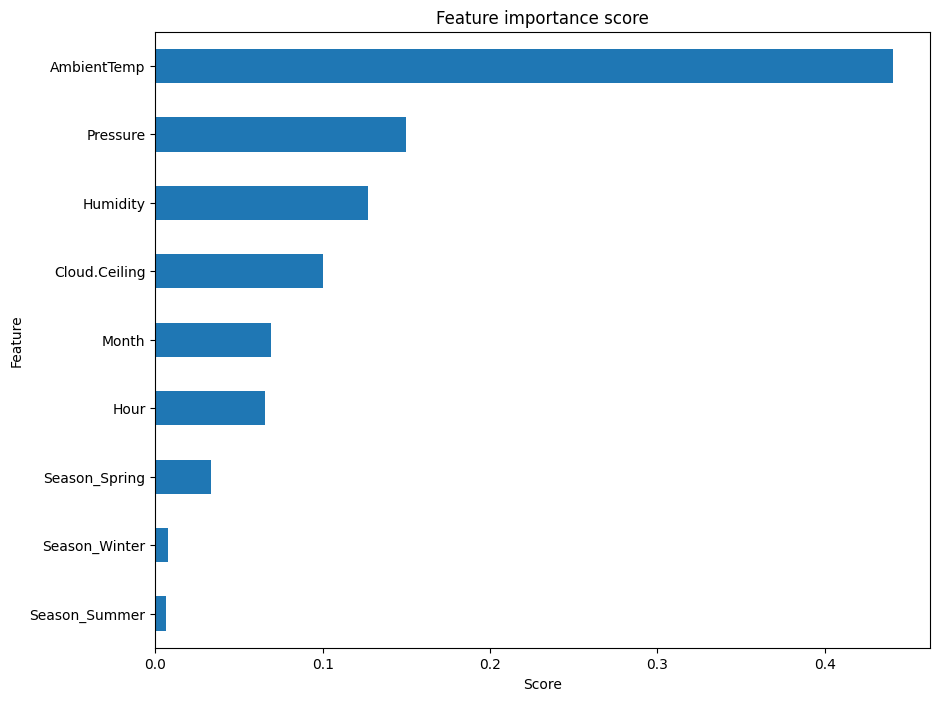

In [121]:
# Feature importance in random forest
show_feature_importance(rf)

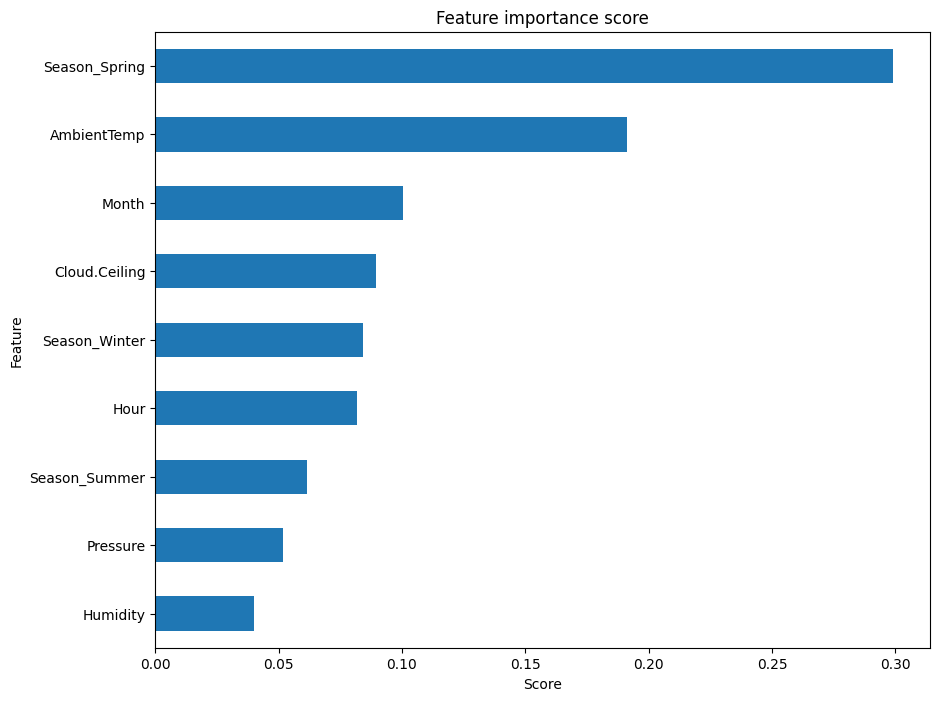

In [122]:
# Feature importance in XGB
show_feature_importance(xgb)

## Hyperparameter Tuning

In [147]:
from sklearn.pipeline import Pipeline

# Define pipeline for each model
def get_model_pipeline(model_name: str) -> Pipeline:
    """
    Create a pipeline for a specific model.
    
    Parameters:
    -----------
    model_name : str
        Name of the model to create pipeline for
        
    Returns:
    --------
    Pipeline
        Scikit-learn pipeline with the specified model
    """
    pipelines = {
        'randomforest': Pipeline([
            ('rf', RandomForestRegressor(random_state=42))
        ]),
        'xgboost': Pipeline([
            ('xgb', XGBRegressor(random_state=42))
        ])
    }
    
    return pipelines.get(model_name.lower())

# Define hyperparameters for each model
def get_hyperparameters(model_name: str) -> dict:
    """
    Get hyperparameter grid for a specific regression model.
    
    Parameters:
    -----------
    model_name : str
        Name of the model to get hyperparameters for
        
    Returns:
    --------
    dict
        Dictionary of hyperparameters for grid search
    """
    import numpy as np
    
    hyperparameters = {
        'linearregression': {
            'lr__fit_intercept': [True, False],
            'lr__normalize': [True, False],
        },
        
        'ridge': {
            'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
            'ridge__fit_intercept': [True, False],
            'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
        },
        
        'lasso': {
            'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
            'lasso__fit_intercept': [True, False],
            'lasso__max_iter': [1000, 2000, 3000],
            'lasso__selection': ['cyclic', 'random']
        },
        
        'elasticnet': {
            'elasticnet__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
            'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
            'elasticnet__fit_intercept': [True, False],
            'elasticnet__max_iter': [1000, 2000, 3000]
        },
        
        'svr': {
            'svr__C': [0.1, 1, 10, 100],
            'svr__epsilon': [0.01, 0.1, 0.2, 0.5],
            'svr__kernel': ['linear', 'poly', 'rbf'],
            'svr__degree': [2, 3, 4],  # Only relevant for poly kernel
            'svr__gamma': ['scale', 'auto', 0.1, 1]
        },
        
        'randomforest': {
            'rf__n_estimators': [100, 200],
            'rf__criterion': ['squared_error'],  # Regression criteria
            'rf__max_depth': [15],
            'rf__min_samples_split': [5, 10],
            'rf__min_samples_leaf': [3, 5],
            'rf__max_features': ['sqrt']
        },
        
        'xgboost': {
            'xgb__eta': [float(x) for x in np.linspace(0, 0.5, num = 5)],
            'xgb__learning_rate': [0.01, 0.1],
            'xgb__n_estimators': [50, 100],
            'xgb__max_depth': [5, 7, 9],
            'xgb__colsample_bytree': [0.8, 1.0],
            'xgb__gamma': [0.1, 0.2]
            # 'xgb__objective': ['reg:squarederror']  # Regression objective
        },
        
        'gradientboosting': {
            'gb__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'gb__n_estimators': [50, 100, 200],
            'gb__max_depth': [3, 5, 7],
            'gb__min_samples_split': [2, 5, 10],
            'gb__min_samples_leaf': [1, 2, 4],
            'gb__subsample': [0.8, 0.9, 1.0],
            'gb__loss': ['squared_error', 'absolute_error', 'huber', 'quantile']  # Regression losses
        },
        
        'knn': {
            'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
            'knn__weights': ['uniform', 'distance'],
            'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
            'knn__p': [1, 2]  # 1 for manhattan_distance, 2 for euclidean_distance
        },
        
        'decisiontree': {
            'dt__criterion': ['squared_error', 'absolute_error', 'poisson'],  # Regression criteria
            'dt__max_depth': [None, 5, 10, 15, 20],
            'dt__min_samples_split': [2, 5, 10],
            'dt__min_samples_leaf': [1, 2, 4],
            'dt__max_features': ['sqrt', 'log2', None]
        }
    }
    
    return hyperparameters.get(model_name.lower())

# Define approach for a single model hyperparameter tuning
def tune_single_model(
    model_name: str,
    X_train,
    y_train,
    X_test,
    y_test,
    scoring='accuracy',
    plot_learning_curves=True,
    progress_bar=False
) -> tuple:
    """
    Tune a single model using grid search.
    
    Parameters:
    -----------
    model_name : str
        Name of the model to tune
    X_train, y_train : array-like
        Training data
    X_test, y_test : array-like
        Test data
    scoring : str, optional (default='accuracy')
        Metric to optimize
    plot_learning_curves : bool, optional (default=True)
        Whether to plot learning curves
    progress_bar : bool, optional (default=False)
        Whether to show progress bar
        
    Returns:
    --------
    tuple
        (fitted GridSearchCV object, fitting time)
    """
    # Get pipeline and hyperparameters for the specified model
    pipeline = get_model_pipeline(model_name)
    params = get_hyperparameters(model_name)
    
    if pipeline is None or params is None:
        raise ValueError(f"Model {model_name} not found in configuration")
    
    # Create single-model dictionary for grid_pipe
    pipedict = {model_name: pipeline}
    param_grid = {model_name: params}
    
    # Run grid search
    fitted_models, fit_times = grid_pipe(
        pipedict=pipedict,
        param_grid=param_grid,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        scoring=scoring,
        plot_learning_curves=plot_learning_curves,
        progress_bar=progress_bar
    )
    
    return fitted_models[model_name], fit_times[0]

# Define approach for all model hyperparameter tuning
def tune_all_models(
    X_train,
    y_train,
    X_test,
    y_test
) -> tuple:
    """
    Tune multiple classification models simultaneously using grid search.
    
    Parameters:
    -----------
    X_train, y_train : array-like
        Training data
    X_test, y_test : array-like
        Test data
        
    Returns:
    --------
    tuple
        (dictionary of fitted GridSearchCV objects for each model,
         list of fitting times for each model)
    """

    # Store all pipelines
    all_pipelines = {
        name: get_model_pipeline(name)
        for name in ['linearregression', 'ridge', 'lasso', 'elasticnet', 'svr', 
                    'randomforest', 'xgboost', 'gradientboosting', 'knn', 'decisiontree']
    }

    # Store all hyperparameters that will be tested
    all_hyperparameters = {
        name: get_hyperparameters(name)
        for name in ['linearregression', 'ridge', 'lasso', 'elasticnet', 'svr', 
                    'randomforest', 'xgboost', 'gradientboosting', 'knn', 'decisiontree']
    }

    # Run grid search
    fitted_models, times = grid_pipe(
        pipedict=all_pipelines,
        param_grid=all_hyperparameters,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

    return fitted_models, times

The parameter variations here are small because the computing power of my local pc so it needs to adjusts to the existing resources.

In [123]:
# # Function for best hyperparameters found during the tuning process
# def show_best_hyperparameter(model):
#     print(model.best_estimator_.get_params())

### Tuning Random Forest

<b>Commonly tuned hyperparameters in Random Forest:</b> (<a href='https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html'>Sklearn Random Forest Documentation</a>)

- n_estimators: the number of trees to be built in the forest.
- max_samples: the maximum number of samples to be drawn from the total training set for building each tree (after the bootstrap process).

The remaining hyperparameters are the same as in Decision Trees:

- criterion: the method used to measure impurity in features (gini, entropy). This is for classification; for regression, it's different. It determines which feature becomes the root/node (squared_error, poisson).
- max_depth: the maximum depth of each tree to prevent overfitting.
- min_sample_split: the minimum number of samples required at a node to create a new leaf (to avoid having too few samples, which can lead to overfitting).
- min_sample_leaf: the minimum number of samples required in a leaf for the leaf to be formed (to avoid having too few samples, which can lead to overfitting).
- ccp_alpha: if the cost/error of a leaf/subtree is greater than ccp_alpha, that subtree will be pruned, minimizing the error/variance of the model.

In [125]:
# ## Original Implementation
# # Hyperparameter Tuning for random forest
# from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# #Initiate hyperparameters used and their values
# n_estimators = [int(x) for x in np.linspace(1, 200, 50)]
# criterion = ['squared_error', 'poisson']
# max_depth = [int(x) for x in np.linspace(50, 180, 5)]
# min_samples_split = [2, 5, 10, 50]
# min_samples_leaf = [1, 2, 5, 8, 20, 30] 

# #Collecting all hyperparameters into a single dictionary
# hyperparameters = dict(n_estimators=n_estimators, 
#                        criterion=criterion, 
#                        max_depth=max_depth,
#                        min_samples_split=min_samples_split,
#                        min_samples_leaf=min_samples_leaf)

# #Initiate tuned model
# rf = RandomForestRegressor()
# # rf_tuned = GridSearchCV(dt, hyperparameters, cv=5, scoring='r2')
# rf_tuned = RandomizedSearchCV(rf, hyperparameters, scoring='r2', cv=5, error_score='raise')
# rf_tuned.fit(X_train, y_train)

# #Tuned model evaluation
# eval_regression(rf_tuned)

In [126]:
# # Best hyperparameter in random forest
# show_best_hyperparameter(rf_tuned)

In [127]:
# # Retrieving the best hyperparameters for random forest (similar to show_best_hyperparameter code before, but only shows the ones that we used)
# best_params = rf_tuned.best_params_
# best_params

In [81]:
# #Learning curve for hyperparameters

# # Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# # param_values = [int(x) for x in np.linspace(50, 180, 5)] # n_estimators
# # param_values = [int(x) for x in np.linspace(50, 180, 5)] # max_depth
# # param_values = [int(x) for x in np.linspace(2, 10, 2)] # min_samples_split
# param_values = [int(x) for x in np.linspace(2, 10, 2)] # min_samples_leaf

# train_scores = []
# test_scores = []

# for i in param_values:
#     model = RandomForestRegressor(min_samples_leaf=i) # Change based on what hyperparameter that we used
#     model.fit(x_train, y_train)

#     # eval on train
#     y_pred_train_proba = model.predict_proba(x_train)
#     train_r2 = r2_score(y_train, y_pred_train_proba[:,1])
#     train_scores.append(train_r2)

#     # eval on test
#     y_pred_proba = model.predict_proba(x_test)
#     test_r2 = r2_score(y_test, y_pred_proba[:,1])
#     test_scores.append(test_r2)

#     print('Param value: ' + str(i) + '; train: ' + str(train_r2) + '; test: '+ str(test_r2))

# plt.title('Learning Curve | Hyperparameter : min_sample_leaf | Random Forest') # Change based on what hyperparameter that we used
# plt.ylabel('R2 Score')
# plt.xlabel('min_sample_leaf') # Change based on what hyperparameter that we used
# plt.plot(param_values, train_scores, label='Train')
# plt.plot(param_values, test_scores, label='Test')
# plt.legend()
# plt.show()


Evaluating rf__n_estimators for randomforest...
rf__n_estimators: 100; train: 0.949; test: 0.647; diff: 0.303
rf__n_estimators: 200; train: 0.950; test: 0.648; diff: 0.302


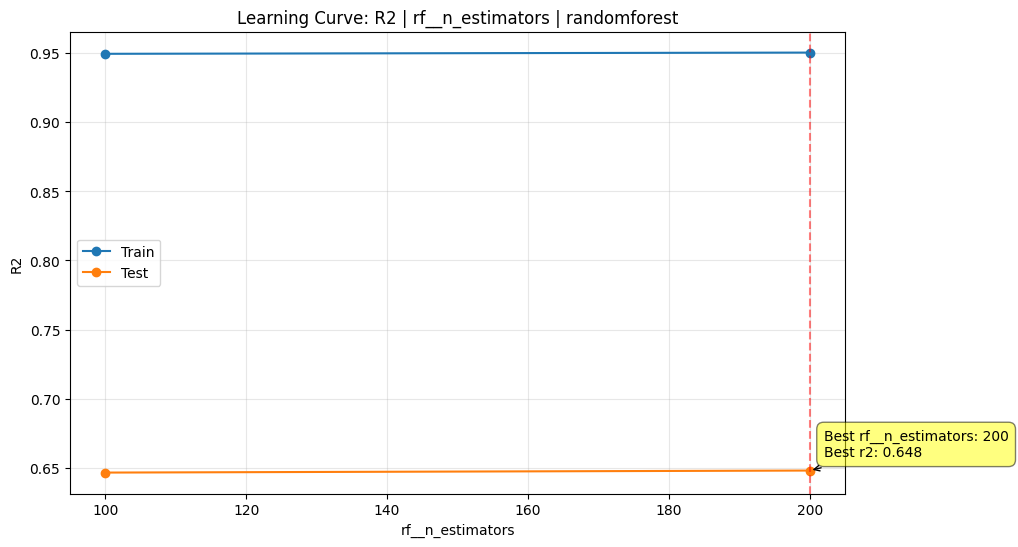


Evaluating rf__min_samples_split for randomforest...
rf__min_samples_split: 5; train: 0.920; test: 0.649; diff: 0.271
rf__min_samples_split: 10; train: 0.869; test: 0.650; diff: 0.219


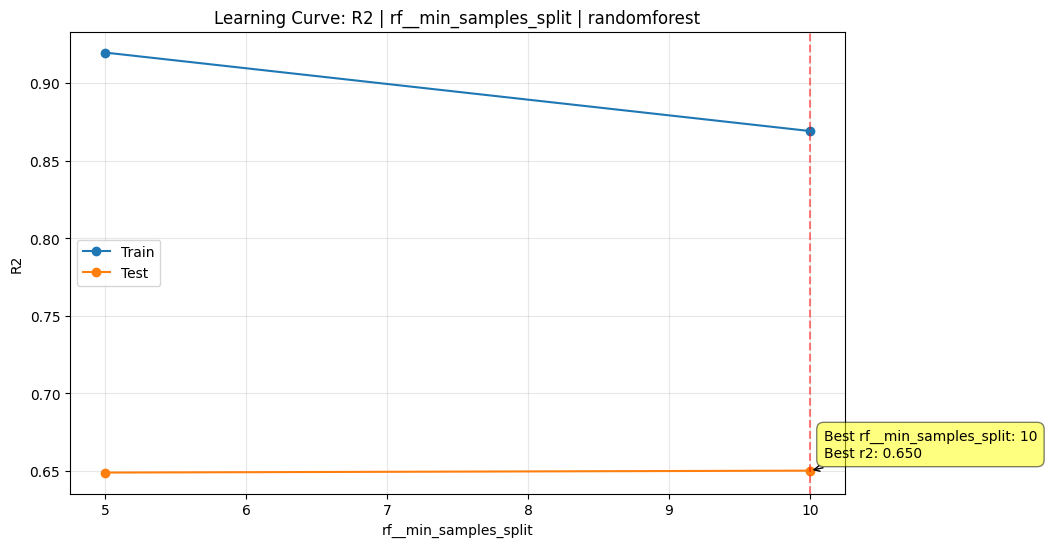


Evaluating rf__min_samples_leaf for randomforest...
rf__min_samples_leaf: 3; train: 0.870; test: 0.652; diff: 0.218
rf__min_samples_leaf: 5; train: 0.815; test: 0.651; diff: 0.163


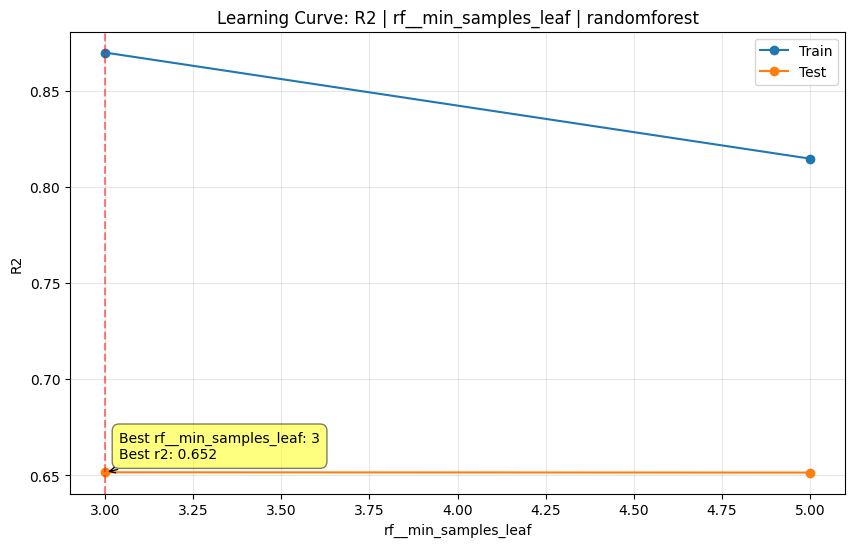

Fitting 15 folds for each of 8 candidates, totalling 120 fits

Grid Search Results for randomforest:
--------------------------------------------------
Total Fit Time: 45.132s
Best r2: 0.642

Best Parameters:
rf__criterion: squared_error
rf__max_depth: 15
rf__max_features: sqrt
rf__min_samples_leaf: 3
rf__min_samples_split: 5
rf__n_estimators: 200



In [140]:
rf_model, rf_time = tune_single_model(
    model_name='randomforest',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    scoring='r2',
    plot_learning_curves=True
)

### Tuning XGBoost

<b>Commonly tuned hyperparameters in XGBoost:</b>  (<a href='https://xgboost.readthedocs.io/en/latest/parameter.html'>XGBoost Documentation</a>)

- <b>Tree architecture-related:</b>
    - max_depth: the maximum depth of the tree to prevent overfitting.
    - min_child_weight: the minimum weight (or the number of samples if the total weight equals 1) a node should have to create a new leaf (to avoid having too few, causing overfitting).
    - gamma: the minimum loss/error reduction required to make a new leaf.
    - tree_method: the method XGBoost uses to build a tree. The algorithm we are learning is tree_method = exact. Other references can be found <a href='https://xgboost.readthedocs.io/en/latest/treemethod.html'>here</a>.

- <b>Boosting process subsampling:</b> Instead of using the entire training data in each iteration, we can use a sample in each iteration.
    - subsample: how much of the row samples to be used for sampling at each step. 1 for all rows.
    - colsample_bytree: how many features to be used. 1 for all features.

- <b>Control learning rate:</b>
    - eta: the step size for updating the feature weight in XGBoost, value range: 0-1. Smaller eta provides more fine-grained corrections but requires more boosting iterations.
        - In sklearn, the hyperparameter name is learning_rate.

- <b>Regularization in XGBoost:</b>
    - lambda: the regularization term on L2 norm.
    - alpha: the regularization term on L1 norm.

- <b>Learning task in XGBoost:</b>
    - objective: the objective function used, such as calculating error in regression.
    - eval_metric: evaluation metrics used on the validation data (e.g., rmse, mae, auc).
    - seed: random state.

- <b>Others:</b>
    - scale_pos_weight: if the data is imbalanced, this parameter is used to adjust the weight of each label.
    
- <b>Other parameters for model checking and debugging:</b>
    - verbose: to display detailed log information during the model training. 0: no messages; 1: display warnings only; 2: display info (deprecated examples); 3: debug: detailed training information for the model.

In [142]:
# #Hyperparameter tuning for xgb
# from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# #Initiate hyperparameters used and their values
# max_depth = [int(x) for x in np.linspace(5, 20, 11)]
# min_child_weight = [int(x) for x in np.linspace(1, 20, 11)]
# gamma = [float(x) for x in np.linspace(0, 3, num = 11)]
# tree_method = ['auto', 'exact', 'approx']

# colsample_bytree = [float(x) for x in np.linspace(0, 1, 11)]
# eta = [float(x) for x in np.linspace(0, 1, num = 100)]

# # lambda = [float(x) for x in np.linspace(0, 1, 11)]
# alpha = [float(x) for x in np.linspace(0, 1, 11)]

# #Collecting all hyperparameters into a single dictionary
# hyperparameters = dict(max_depth=max_depth, 
#                        min_child_weight=min_child_weight, 
#                        gamma=gamma,
#                        tree_method=tree_method,
#                        colsample_bytree=colsample_bytree,
#                        eta=eta,
#                        alpha=alpha)

# #Initiate tuned model
# xg = XGBRegressor()
# # xg_tuned = GridSearchCV(xg, hyperparameters, cv=5, scoring='r2')
# xg_tuned = RandomizedSearchCV(xg, hyperparameters, scoring='r2', cv=5, error_score='raise')
# xg_tuned.fit(x_train,y_train)

# # Evaluation
# eval_regression(xg_tuned)

In [143]:
# # Best hyperparameter in xgb
# show_best_hyperparameter(xg_tuned)

In [144]:
# # Retrieving the best hyperparameters for xgb (similar to show_best_hyperparameter code before, but only shows the ones that we used)
# best_params = xg_tuned.best_params_
# best_params

In [145]:
# #Learning curve for hyperparameters

# # Hyperparameter that will be tested and their values (can be found in best hyperparameter before or experiment with others)
# # param_values = [int(x) for x in np.linspace(5, 20, 11)] #max_depth
# # param_values = [int(x) for x in np.linspace(1, 20, 11)] #min_child_weight
# # param_values = [float(x) for x in np.linspace(0, 3, num = 11)] #gamma
# # param_values = ['auto', 'exact', 'approx'] #tree_method
# # param_values = [float(x) for x in np.linspace(0, 1, 11)] #colsample_bytree
# # param_values = [float(x) for x in np.linspace(0, 1, 100)] #eta
# # param_values = [float(x) for x in np.linspace(0, 1, 11)] #lambda
# param_values = [float(x) for x in np.linspace(0, 1, 11)] #alpha

# train_scores = []
# test_scores = []

# for i in param_values:
#     model = XGBRegressor(alpha=i) # Change based on what hyperparameter that we used
#     model.fit(x_train, y_train)

#     # eval on train
#     y_pred_train_proba = model.predict_proba(x_train)
#     train_r2 = r2_score(y_train, y_pred_train_proba[:,1])
#     train_scores.append(train_r2)

#     # eval on test
#     y_pred_proba = model.predict_proba(x_test)
#     test_r2 = r2_score(y_test, y_pred_proba[:,1])
#     test_scores.append(test_r2)

#     print('Param value: ' + str(i) + '; train: ' + str(train_r2) + '; test: '+ str(test_r2))

# plt.title('Learning Curve | Hyperparameter : alpha | XGB') # Change based on what hyperparameter that we used
# plt.ylabel('AUC')
# plt.xlabel('alpha') # Change based on what hyperparameter that we used
# plt.plot(param_values, train_scores, label='Train')
# plt.plot(param_values, test_scores, label='Test')
# plt.legend()
# plt.show()


Evaluating xgb__eta for xgboost...
xgb__eta: 0.0; train: -0.000; test: -0.000; diff: 0.000
xgb__eta: 0.125; train: 0.744; test: 0.651; diff: 0.093
xgb__eta: 0.25; train: 0.805; test: 0.646; diff: 0.159
xgb__eta: 0.375; train: 0.845; test: 0.629; diff: 0.216
xgb__eta: 0.5; train: 0.862; test: 0.610; diff: 0.252


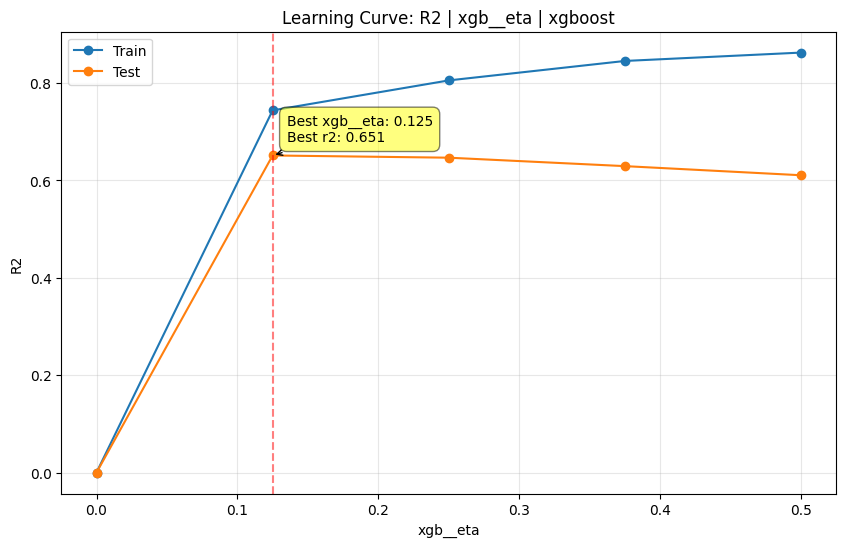


Evaluating xgb__learning_rate for xgboost...
xgb__learning_rate: 0.01; train: 0.516; test: 0.511; diff: 0.005
xgb__learning_rate: 0.1; train: 0.731; test: 0.651; diff: 0.080


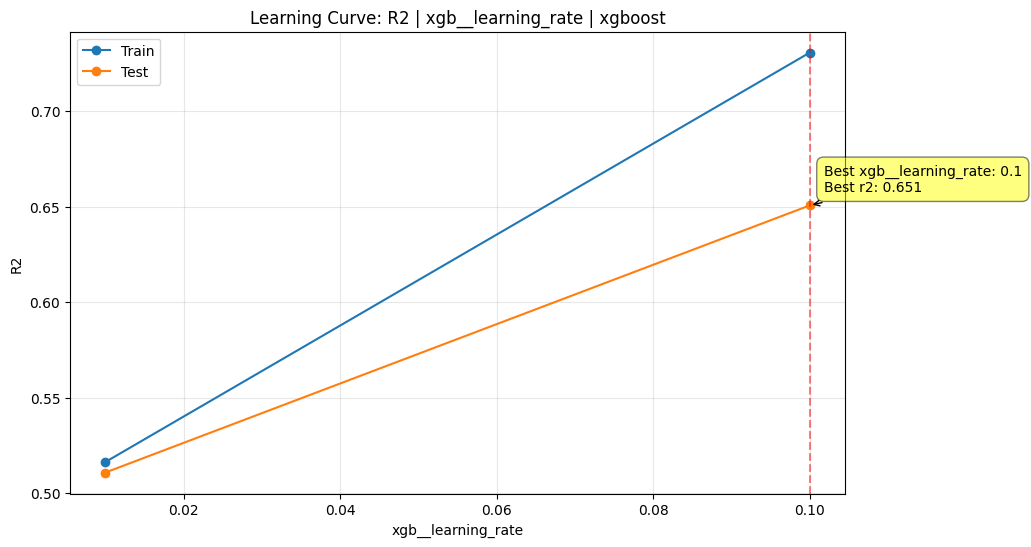


Evaluating xgb__n_estimators for xgboost...
xgb__n_estimators: 50; train: 0.758; test: 0.643; diff: 0.115
xgb__n_estimators: 100; train: 0.815; test: 0.639; diff: 0.177


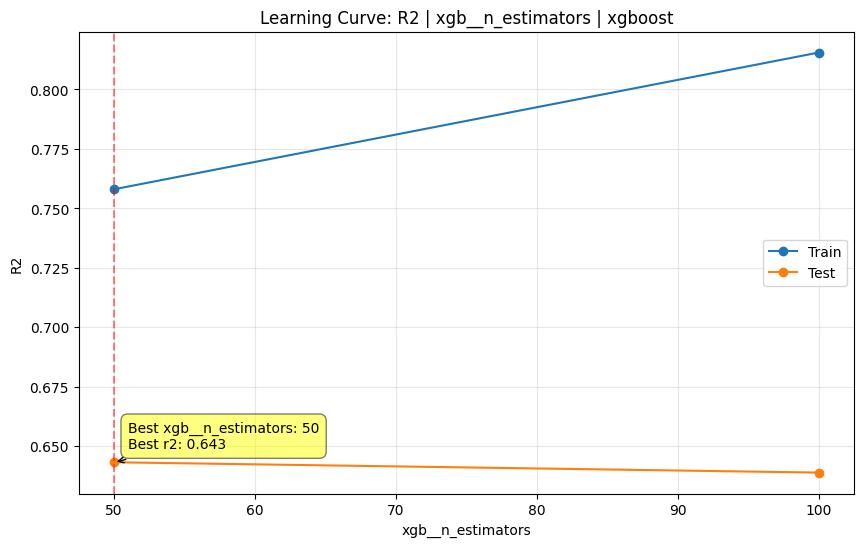


Evaluating xgb__max_depth for xgboost...
xgb__max_depth: 5; train: 0.757; test: 0.644; diff: 0.112
xgb__max_depth: 7; train: 0.877; test: 0.636; diff: 0.242
xgb__max_depth: 9; train: 0.962; test: 0.617; diff: 0.345


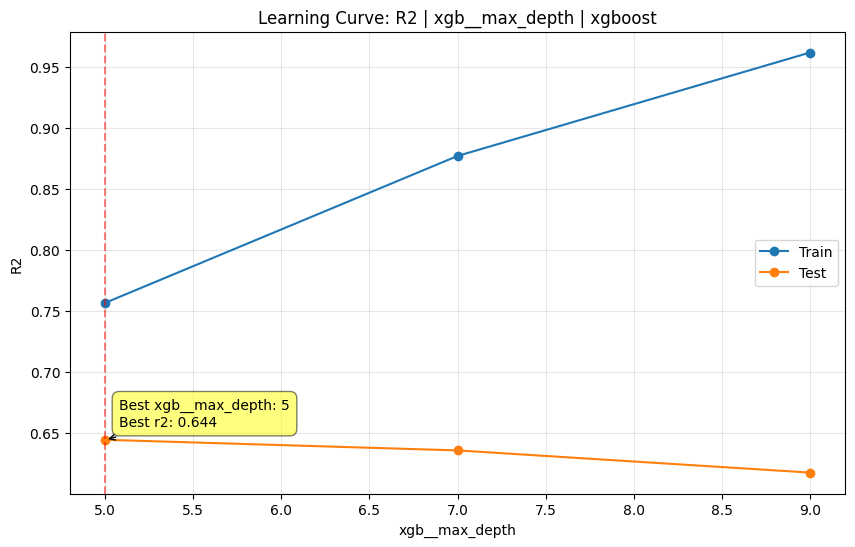


Evaluating xgb__colsample_bytree for xgboost...
xgb__colsample_bytree: 0.8; train: 0.813; test: 0.633; diff: 0.179
xgb__colsample_bytree: 1.0; train: 0.815; test: 0.639; diff: 0.177


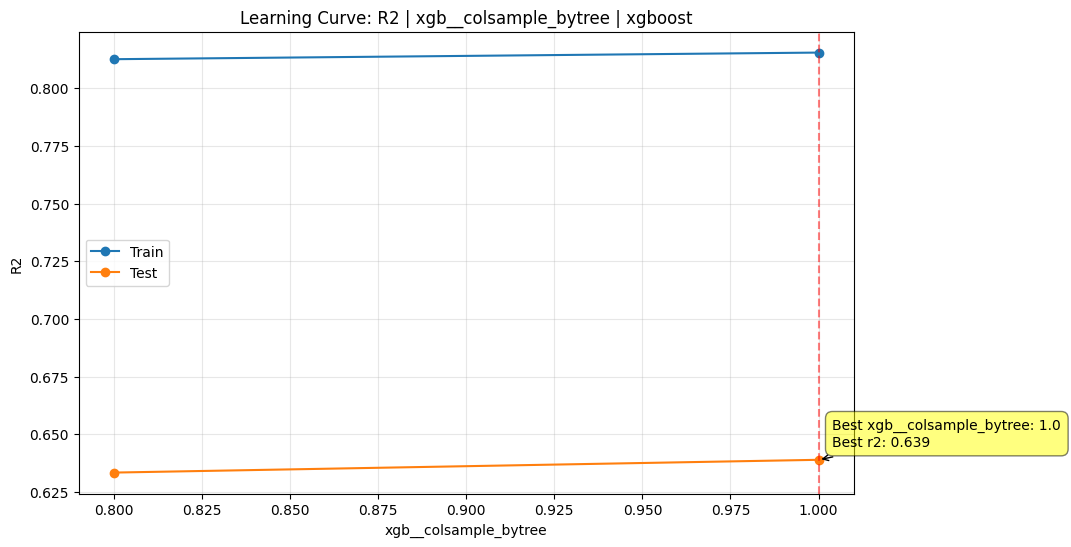


Evaluating xgb__gamma for xgboost...
xgb__gamma: 0.1; train: 0.823; test: 0.638; diff: 0.184
xgb__gamma: 0.2; train: 0.819; test: 0.638; diff: 0.181


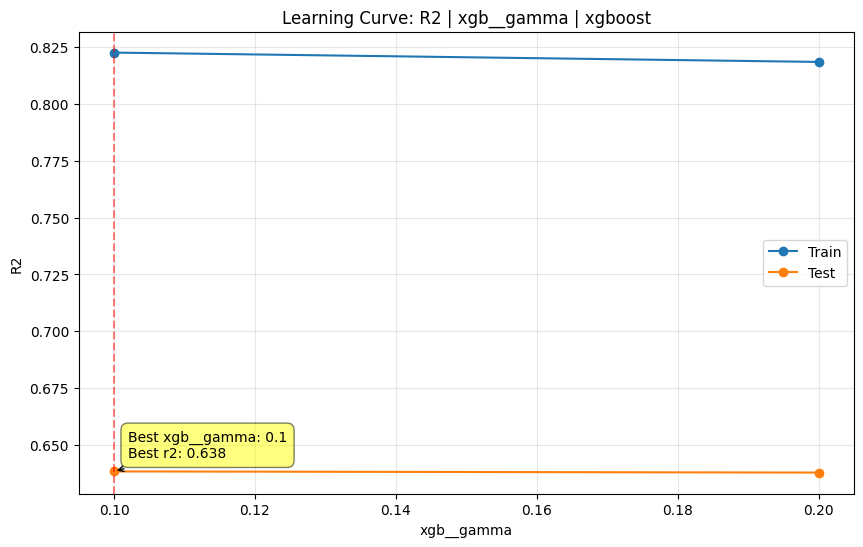

Fitting 15 folds for each of 240 candidates, totalling 3600 fits

Grid Search Results for xgboost:
--------------------------------------------------
Total Fit Time: 184.998s
Best r2: 0.643

Best Parameters:
xgb__colsample_bytree: 0.8
xgb__eta: 0.0
xgb__gamma: 0.1
xgb__learning_rate: 0.1
xgb__max_depth: 7
xgb__n_estimators: 100



In [148]:
xgb_model, xgb_time = tune_single_model(
    model_name='xgboost',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    scoring='r2',
    plot_learning_curves=True
)

## Train Tuned Models

In [149]:
# Initiatialize object for each model
rf_tuned = RandomForestRegressor(random_state=42, criterion = 'squared_error', max_depth=15, max_features = 'sqrt', min_samples_leaf = 3, min_samples_split=5, n_estimators = 200)
xgb_tuned = XGBRegressor(random_state=42, eta=0.125, colsample_bytree= 0.8, learning_rate=0.1, gamma=0.1, max_depth = 5, n_estimators=100, tree_method='approx')

models = [rf_tuned, xgb_tuned]

# Train models
for model in models :
    model.fit(X_train, y_train)

## Evaluate Tuned Models

### Random Forest

In [150]:
results_rf_tuned = eval_regression(rf_tuned, X_test, y_test, X_train, y_train)

Performance Metrics for RandomForestRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  2.9846 ± 0.0547
  Train: 2.1829 ± 0.0153

RMSE:
  Test:  4.2437 ± 0.0905
  Train: 3.1147 ± 0.0180

R2:
  Test:  0.6419 ± 0.0125
  Train: 0.8072 ± 0.0021

MAPE:
  Test:  0.5325 ± 0.0357
  Train: 0.3802 ± 0.0058

Single Run Metrics:

MAE:
  Test:  2.9087
  Train: 2.1889

RMSE:
  Test:  4.1880
  Train: 3.1336

MAPE:
  Test:  0.5247
  Train: 0.3814

R2:
  Test:  0.6558
  Train: 0.8049


### Xtreme Gradient Boost

In [151]:
results_xgb_tuned = eval_regression(xgb_tuned, X_test, y_test, X_train, y_train)

Performance Metrics for XGBRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  3.0577 ± 0.0466
  Train: 2.8015 ± 0.0139

RMSE:
  Test:  4.2940 ± 0.0824
  Train: 3.9307 ± 0.0185

R2:
  Test:  0.6334 ± 0.0114
  Train: 0.6930 ± 0.0026

MAPE:
  Test:  0.5413 ± 0.0352
  Train: 0.4926 ± 0.0064

Single Run Metrics:

MAE:
  Test:  3.0035
  Train: 2.8180

RMSE:
  Test:  4.2492
  Train: 3.9589

MAPE:
  Test:  0.5300
  Train: 0.4970

R2:
  Test:  0.6456
  Train: 0.6886


## Save Tuned models

In [152]:
import joblib
# import pickle

# Save the model using joblib
joblib.dump(rf_tuned, 'tuned_rf_model.joblib')
joblib.dump(xgb_tuned, 'tuned_xgb_model.joblib')

# # Save the model using pickle
# with open('tuned_rf_model.pkl', 'wb') as file:
#     pickle.dump(rf_tuned, file)

# with open('tuned_xb_model.pkl', 'wb') as file:
#     pickle.dump(xgb_tuned, file)

['tuned_xgb_model.joblib']

# Comparison of Results Before and After Hyperparameter Tuning

**Evaluate RandomForestRegressor**

A. Before Hyperparameter Tuning
   - MAE (test): 2.9399 ± 0.0584
   - RMSE (test): 4.2957 ± 0.0875
   - MAPE (test): 0.5180 ± 0.0348
   - R2 (test): 0.6331 ± 0.0124

B. After Hyperparameter Tuning
   - MAE (test): 2.9846 ± 0.0547
   - RMSE (test): 4.2437 ± 0.0905
   - MAPE (test): 0.5325 ± 0.0357
   - R2 (test): 0.6419 ± 0.0125

**Evaluate XGBRegressor**

A. Before Hyperparameter Tuning
- MAE (test): 3.0283 ± 0.0556
- RMSE (test): 4.3444 ± 0.0922
- MAPE (test): 0.5280 ± 0.0357
- R2 (test): 0.6247 ± 0.0131

B. After Hyperparameter Tuning
- MAE (test): 3.0577 ± 0.0466
- RMSE (test): 4.2940 ± 0.0824
- MAPE (test): 0.5413 ± 0.0352
- R2 (test): 0.6334 ± 0.0114

It does increse the R2 score even just a little but further tuning obviously still needs to be done like using more variation in the parameters, and we also have to experiment with other combination of features in training. But for now this is good enough.